In [5]:
# Import packages and declare control vars

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from openpyxl import load_workbook

In [6]:
# Declare paths, files, and load data

path_TTpaper_SI = 'C:/Users/skar/repos/US_WWTP_GHG/supplementary_databases'
fi_SI_A = 'supplementary_database_A.xlsx'
fi_SI_B = 'supplementary_database_B.xlsx'
fi_SI_C = 'supplementary_database_C.xlsx'

path_data = 'C:/Users/skar/Box/FY25_Water Analysis_FCG share/8. Daniel Z/2025 Project (CURRENT)'
fi_data = 'Official_Top_50_Plants_Data_Repository.xlsx'
fi_select_plants_sheet = 'Top 50 Treatment Plants'
fi_all_plants = 'all_wwtps_data_070124'

path_out = 'C:/Users/skar/Box/saura_self/Proj - Water tool analysis/data/output'
fi_out = 'survey_data_repo.xlsx'

df_SI_A = pd.read_excel(path_TTpaper_SI + '/' + fi_SI_A, header=0)
df_SI_B = pd.read_excel(path_TTpaper_SI + '/' + fi_SI_B, header=0)
df_SI_C = pd.read_excel(path_TTpaper_SI + '/' + fi_SI_C, header=0)
df_select_plants = pd.read_excel(path_data + '/' + fi_data, fi_select_plants_sheet, header=0)
df_all_plants = pd.read_excel(path_data + '/' + fi_data, fi_all_plants, header=0)

write_to_excel_tab = True


In [7]:
# View tables

print ("SI Table A:\n", df_SI_A.head())
print ("SI Table B:\n", df_SI_B.head())
print ("SI Table C:\n", df_SI_C.head())
print ("Selected Plants, columns:\n", list(df_select_plants.columns))
#print ("All Plants Data:\n", df_all_plants.head())

SI Table A:
    FACILITY_ID     CWNS_NUM  AED  AND  AS  AS-A2O  AS-BDENIT  AS-EA  AS-OD  \
0      1159112  30000044001    0    0   0       0          0      0      0   
1      1159221  30000180001    0    1   0       0          0      0      0   
2      1160522  28001370001    0    0   0       0          0      0      0   
3      1164458  41000244001    1    0   1       0          0      0      0   
4      1165962  47000010001    0    0   0       1          0      0      0   

   AS-P  ...  N2  O1  O1E  O2  O3  O5  O6  TT_IDENTIFIED  \
0     0  ...   0   0    0   0   0   0   0              1   
1     0  ...   0   0    0   0   0   0   0              1   
2     0  ...   0   0    0   0   0   0   0              1   
3     0  ...   0   0    0   0   0   0   0              1   
4     0  ...   0   0    0   0   0   0   0              1   

                              TT_ASSIGN_NOTE  UP_ID_NOTE  
0  Assigned based on reported unit processes         NaN  
1  Assigned based on reported unit proc

In [ ]:
# Data clean up and save

# Dictionary to store all DataFrames
all_data = {}

# Filter completed data set
df_select = df_select_plants[df_select_plants['Study Status'] == 'Complete'].copy()
# remove columns with all NaN values
df_select = df_select.dropna(axis=1, how='all')
# remove rows with all NaN values
df_select = df_select.dropna(axis=0, how='all')
# reset index
df_select = df_select.reset_index(drop=True)
# Standardize column names by stripping leading/trailing spaces
df_select.columns = df_select.columns.str.strip()
# Standardize string entries by stripping leading/trailing spaces
df_select = df_select.map(lambda x: x.strip() if isinstance(x, str) else x)
# Standardize column names by replacing spaces with underscores
df_select.columns = df_select.columns.str.replace(' ', '_')
# Standardize column names by replacing slashes with underscores
df_select.columns = df_select.columns.str.replace('/', '_')
# Standardize column names by replacing hyphens with underscores
df_select.columns = df_select.columns.str.replace('-', '_')

df_select.drop(columns=['STUDY_STATUS',                         
                        'FOIA_STATUS_(Not_Requested,_Requested,_Filled,_Denied,_Other)', 
                        'PRIMARY_CONTACT_NAME',
                        'PRIMARY_CONTACT_EMAIL', 
                        'RESPONSE_STATUS',
                        'Study_Status', 
                        'DATA_URL',
                        'PROVIDED_TT_DATA',
                        'REQUEST_CODE',                        
                        'OTHER_NOTES'
], inplace=True)

# Function to finalize DataFrame before adding to all_data
def finalize_dataframe(df, df_name):
    """
    Finalize DataFrame by removing duplicates and ensuring data quality
    
    Parameters:
    - df: DataFrame to finalize
    - df_name: Name of the DataFrame for logging
    
    Returns:
    - Cleaned DataFrame
    """
    print(f"Finalizing '{df_name}' DataFrame...")
    
    # Check initial state
    initial_rows = len(df)
    initial_cols = len(df.columns)
    print(f"  Initial: {initial_rows} rows, {initial_cols} columns")
    
    # Remove duplicate rows based on CWNS_ID (keep first occurrence)
    df_clean = df.drop_duplicates(subset=['CWNS_ID'], keep='first')
    
    # Check for duplicate removal
    if len(df_clean) != initial_rows:
        removed_rows = initial_rows - len(df_clean)
        print(f"  Removed {removed_rows} duplicate CWNS_ID rows")
    
    # Remove duplicate columns (keep first occurrence)
    df_clean = df_clean.loc[:, ~df_clean.columns.duplicated()]
    
    # Check for duplicate column removal
    if len(df_clean.columns) != initial_cols:
        removed_cols = initial_cols - len(df_clean.columns)
        print(f"  Removed {removed_cols} duplicate columns")
    
    # Reset index
    df_clean = df_clean.reset_index(drop=True)
    
    # Final state
    final_rows = len(df_clean)
    final_cols = len(df_clean.columns)
    print(f"  Final: {final_rows} rows, {final_cols} columns")
    
    # Validate CWNS_ID uniqueness
    unique_cwns = df_clean['CWNS_ID'].nunique()
    if unique_cwns != final_rows:
        print(f"  WARNING: CWNS_ID not unique! {unique_cwns} unique vs {final_rows} rows")
    else:
        print(f"  ✓ All CWNS_IDs are unique")
    
    return df_clean

# Check flow data availability
df_sub = df_select[[
'CWNS_ID',
'FACILITY_ID',
'FACILITY_NAME',
'LATITUDE',
'LONGITUDE',
'CITY',
'STATE_CODE',
'AUTHORITY_NAME',
'COUNTY_NAME',

'DESIGN_FLOW',
'DESIGN_FLOW_UNITS',
'ACTUAL_FLOW_MIN',
'ACTUAL_FLOW_MAX',
'ACTUAL_FLOW_AVG',
'ACTUAL_FLOW_UNITS']].copy()
df_sub['CWNS_ID'] = df_sub['CWNS_ID'].astype(int)

print("Rows with no flow data:")
print(df_sub[df_sub['DESIGN_FLOW'].isna() & 
                    df_sub['ACTUAL_FLOW_MIN'].isna() & 
                    df_sub['ACTUAL_FLOW_MAX'].isna() & 
                    df_sub['ACTUAL_FLOW_AVG'].isna()])

# remove rows with no flow data
df_sub = df_sub[~(df_sub['DESIGN_FLOW'].isna() & 
                                df_sub['ACTUAL_FLOW_MIN'].isna() & 
                                df_sub['ACTUAL_FLOW_MAX'].isna() & 
                                df_sub['ACTUAL_FLOW_AVG'].isna())].reset_index(drop=True)
# Finalize and add to all_data
all_data['Flow'] = finalize_dataframe(df_sub, 'Flow')

# Check BOD5 data availability
df_sub = df_select[[
    'CWNS_ID',
    'BOD5_MIN',
    'BOD5_MAX',
    'BOD5_AVG',
    'BOD5_UNITS']].copy()
df_sub['CWNS_ID'] = df_sub['CWNS_ID'].astype(int)
print("Rows with no BOD5 data:")
print(df_sub[df_sub['BOD5_MIN'].isna() & 
                    df_sub['BOD5_MAX'].isna() & 
                    df_sub['BOD5_AVG'].isna()])
# remove rows with no BOD5 data
df_sub = df_sub[~(df_sub['BOD5_MIN'].isna() & 
                                df_sub['BOD5_MAX'].isna() & 
                                df_sub['BOD5_AVG'].isna())].reset_index(drop=True)
# Finalize and add to all_data
all_data['BOD5'] = finalize_dataframe(df_sub, 'BOD5')

# Check CBOD5 data availability
df_sub = df_select[[
    'CWNS_ID',
    'CBOD5_MIN',
    'CBOD5_MAX',
    'CBOD5_AVG',
    'CBOD5_UNITS']].copy()
df_sub['CWNS_ID'] = df_sub['CWNS_ID'].astype(int)
print("Rows with no CBOD5 data:")
print(df_sub[df_sub['CBOD5_MIN'].isna() & 
                    df_sub['CBOD5_MAX'].isna() & 
                    df_sub['CBOD5_AVG'].isna()])
# remove rows with no CBOD5 data
df_sub = df_sub[~(df_sub['CBOD5_MIN'].isna() & 
                               df_sub['CBOD5_MAX'].isna() & 
                                df_sub['CBOD5_AVG'].isna())].reset_index(drop=True)    
# Finalize and add to all_data
all_data['CBOD5'] = finalize_dataframe(df_sub, 'CBOD5')

# Check SS data availability
df_sub = df_select[[  
    'CWNS_ID',
    'SS_MIN',
    'SS_MAX',
    'SS_AVG',
    'SS_UNITS']].copy()
df_sub['CWNS_ID'] = df_sub['CWNS_ID'].astype(int)
print("Rows with no SS data:")
print(df_sub[df_sub['SS_MIN'].isna() & 
                    df_sub['SS_MAX'].isna() & 
                    df_sub['SS_AVG'].isna()])
# remove rows with no SS data
df_sub = df_sub[~(df_sub['SS_MIN'].isna() & 
                               df_sub['SS_MAX'].isna() &
                                df_sub['SS_AVG'].isna())].reset_index(drop=True)
# Finalize and add to all_data
all_data['SS'] = finalize_dataframe(df_sub, 'SS')

# Check VSS data availability
df_sub = df_select[[
    'CWNS_ID',
    'VSS_MIN',
    'VSS_MAX',
    'VSS_AVG',
    'VSS_UNITS']].copy()
df_sub['CWNS_ID'] = df_sub['CWNS_ID'].astype(int)
print("Rows with no VSS data:")
print(df_sub[df_sub['VSS_MIN'].isna() & 
                    df_sub['VSS_MAX'].isna() & 
                    df_sub['VSS_AVG'].isna()])
# remove rows with no VSS data
df_sub = df_sub[~(df_sub['VSS_MIN'].isna() & 
                               df_sub['VSS_MAX'].isna() & 
                                df_sub['VSS_AVG'].isna())].reset_index(drop=True)
# Finalize and add to all_data
all_data['VSS'] = finalize_dataframe(df_sub, 'VSS')

# Check TS data availability
df_sub = df_select[[
    'CWNS_ID',
    'TS_MIN',
    'TS_MAX',
    'TS_AVG',
    'TS_UNITS']].copy()
df_sub['CWNS_ID'] = df_sub['CWNS_ID'].astype(int)
print("Rows with no TS data:") 
print(df_sub[df_sub['TS_MIN'].isna() & 
                    df_sub['TS_MAX'].isna() & 
                    df_sub['TS_AVG'].isna()])
# remove rows with no TS data
df_sub = df_sub[~(df_sub['TS_MIN'].isna() & 
                               df_sub['TS_MAX'].isna() & 
                                df_sub['TS_AVG'].isna())].reset_index(drop=True)
# Finalize and add to all_data
all_data['TS'] = finalize_dataframe(df_sub, 'TS')

# Check TSS data availability
df_sub = df_select[[
    'CWNS_ID',
    'TSS_MIN',
    'TSS_MAX',
    'TSS_AVG',
    'TSS_UNITS']].copy()   
df_sub['CWNS_ID'] = df_sub['CWNS_ID'].astype(int)
print("Rows with no TSS data:")
print(df_sub[df_sub['TSS_MIN'].isna() &
                    df_sub['TSS_MAX'].isna() & 
                    df_sub['TSS_AVG'].isna()])
# remove rows with no TSS data
df_sub = df_sub[~(df_sub['TSS_MIN'].isna() & 
                               df_sub['TSS_MAX'].isna() & 
                                df_sub['TSS_AVG'].isna())].reset_index(drop=True)
# Finalize and add to all_data
all_data['TSS'] = finalize_dataframe(df_sub, 'TSS')

# Check VTS data availability
df_sub = df_select[[
    'CWNS_ID',
    'VTS_MIN',
    'VTS_MAX',
    'VTS_AVG',
    'VTS_UNITS']].copy()
df_sub['CWNS_ID'] = df_sub['CWNS_ID'].astype(int)
print("Rows with no VTS data:")
print(df_sub[df_sub['VTS_MIN'].isna() & 
                    df_sub['VTS_MAX'].isna() & 
                    df_sub['VTS_AVG'].isna()])
# remove rows with no VTS data
df_sub = df_sub[~(df_sub['VTS_MIN'].isna() & 
                               df_sub['VTS_MAX'].isna() & 
                                df_sub['VTS_AVG'].isna())].reset_index(drop=True)
# Finalize and add to all_data
all_data['VTS'] = finalize_dataframe(df_sub, 'VTS')

# Check TKN data availability
df_sub = df_select[[
    'CWNS_ID',
    'TKN_MIN',
    'TKN_MAX',
    'TKN_AVG',
    'TKN_UNITS']].copy()
df_sub['CWNS_ID'] = df_sub['CWNS_ID'].astype(int)
print("Rows with no TKN data:")
print(df_sub[df_sub['TKN_MIN'].isna() &
                    df_sub['TKN_MAX'].isna() & 
                    df_sub['TKN_AVG'].isna()])
# remove rows with no TKN data
df_sub = df_sub[~(df_sub['TKN_MIN'].isna() & 
                               df_sub['TKN_MAX'].isna() &
                                df_sub['TKN_AVG'].isna())].reset_index(drop=True)
# Finalize and add to all_data
all_data['TKN'] = finalize_dataframe(df_sub, 'TKN')

# Check TN data availability
df_sub = df_select[[
    'CWNS_ID',
    'TN_MIN',
    'TN_MAX',
    'TN_AVG',
    'TN_UNITS']].copy()
df_sub['CWNS_ID'] = df_sub['CWNS_ID'].astype(int)
print("Rows with no TN data:")
print(df_sub[df_sub['TN_MIN'].isna() &
                    df_sub['TN_MAX'].isna() & 
                    df_sub['TN_AVG'].isna()])
# remove rows with no TN data
df_sub = df_sub[~(df_sub['TN_MIN'].isna() & 
                               df_sub['TN_MAX'].isna() & 
                                df_sub['TN_AVG'].isna())].reset_index(drop=True)
# Finalize and add to all_data
all_data['TN'] = finalize_dataframe(df_sub, 'TN')

# Check NH3 data availability
df_sub = df_select[[
    'CWNS_ID',
    'NH3_MIN',
    'NH3_MAX',
    'NH3_AVG',
    'NH3_UNITS',
    'NH3_N_MIN',
    'NH3_N_MAX',
    'NH3_N_AVG',
    'NH3_N_UNITS',
    ]].copy()
df_sub['CWNS_ID'] = df_sub['CWNS_ID'].astype(int)
print("Rows with no NH3 data:")
print(df_sub[df_sub['NH3_MIN'].isna() &
                    df_sub['NH3_MAX'].isna() & 
                    df_sub['NH3_AVG'].isna() &
                    df_sub['NH3_N_MIN'].isna() &
                    df_sub['NH3_N_MAX'].isna() & 
                    df_sub['NH3_N_AVG'].isna()])
# remove rows with no NH3 data
df_sub = df_sub[~(df_sub['NH3_MIN'].isna() & 
                                df_sub['NH3_MAX'].isna() &
                                df_sub['NH3_AVG'].isna() &
                                df_sub['NH3_N_MIN'].isna() &
                                df_sub['NH3_N_MAX'].isna() &
                                df_sub['NH3_N_AVG'].isna())].reset_index(drop=True)
for col in ["NH3_N_MIN", "NH3_MIN", "NH3_N_MAX", "NH3_MAX", "NH3_N_AVG", "NH3_AVG"]:
    df_sub[col] = pd.to_numeric(df_sub[col], errors="coerce")
# convert NH3 columns to NH3_N columns if NH3_N columns are not available
df_sub['NH3_N_MIN'] = np.where(df_sub['NH3_N_MIN'].isna(), df_sub['NH3_MIN'], df_sub['NH3_N_MIN']) * (14.007/17.031)
df_sub['NH3_N_MAX'] = np.where(df_sub['NH3_N_MAX'].isna(), df_sub['NH3_MAX'], df_sub['NH3_N_MAX']) * (14.007/17.031)
df_sub['NH3_N_AVG'] = np.where(df_sub['NH3_N_AVG'].isna(), df_sub['NH3_AVG'], df_sub['NH3_N_AVG']) * (14.007/17.031)
df_sub['NH3_N_UNITS'] = np.where(df_sub['NH3_N_UNITS'].isna(), df_sub['NH3_UNITS'], df_sub['NH3_N_UNITS'])

# Calculate average when both min and max are available but avg is not
df_sub['NH3_N_AVG'] = np.where(df_sub['NH3_N_AVG'].isna() &
                                     ~df_sub['NH3_N_MIN'].isna() &  
                                        ~df_sub['NH3_N_MAX'].isna(),
                                        (df_sub['NH3_N_MIN'] + df_sub['NH3_N_MAX']) / 2,
                                        df_sub['NH3_N_AVG']) 
# drop NH3 columns
df_sub = df_sub.drop(columns=['NH3_MIN', 'NH3_MAX', 'NH3_AVG', 'NH3_UNITS'])
# Finalize and add to all_data
all_data['NH3_N'] = finalize_dataframe(df_sub, 'NH3_N')

# Check NO3_N data availability
df_sub = df_select[[
    'CWNS_ID',
    'NO3_N_MIN',
    'NO3_N_MAX',
    'NO3_N_AVG',
    'NO3_N_UNITS']].copy()
df_sub['CWNS_ID'] = df_sub['CWNS_ID'].astype(int)
print("Rows with no NO3_N data:")
print(df_sub[df_sub['NO3_N_MIN'].isna() &
                    df_sub['NO3_N_MAX'].isna() & 
                    df_sub['NO3_N_AVG'].isna()])
# remove rows with no NO3_N data
df_sub = df_sub[~(df_sub['NO3_N_MIN'].isna() & 
                               df_sub['NO3_N_MAX'].isna() & 
                                df_sub['NO3_N_AVG'].isna())].reset_index(drop=True)
# Finalize and add to all_data
all_data['NO3_N'] = finalize_dataframe(df_sub, 'NO3_N')

# Check NO2_N data availability
df_sub = df_select[[
    'CWNS_ID',
    'NO2_N_MIN',
    'NO2_N_MAX',
    'NO2_N_AVG',
    'NO2_N_UNITS']].copy()
df_sub['CWNS_ID'] = df_sub['CWNS_ID'].astype(int)
print("Rows with no NO2_N data:")
print(df_sub[df_sub['NO2_N_MIN'].isna() &
                    df_sub['NO2_N_MAX'].isna() & 
                    df_sub['NO2_N_AVG'].isna()])
# remove rows with no NO2_N data
df_sub = df_sub[~(df_sub['NO2_N_MIN'].isna() &
                                 df_sub['NO2_N_MAX'].isna() & 
                                  df_sub['NO2_N_AVG'].isna())].reset_index(drop=True)
# Finalize and add to all_data
all_data['NO2_N'] = finalize_dataframe(df_sub, 'NO2_N')

# Check NO3_N+NO2_N data availability
df_sub = df_select[[
    'CWNS_ID',
    'NO3_N+NO2_N_MIN',
    'NO3_N+NO2_N_MAX',
    'NO3_N+NO2_N_AVG',
    'NO3_N+NO2_N_UNITS']].copy()
df_sub['CWNS_ID'] = df_sub['CWNS_ID'].astype(int)
print("Rows with no NO3_N+NO2_N data:")
print(df_sub[df_sub['NO3_N+NO2_N_MIN'].isna() &
                    df_sub['NO3_N+NO2_N_MAX'].isna() & 
                    df_sub['NO3_N+NO2_N_AVG'].isna()])
# remove rows with no NO3_N+NO2_N data
df_sub = df_sub[~(df_sub['NO3_N+NO2_N_MIN'].isna() & 
                               df_sub['NO3_N+NO2_N_MAX'].isna() & 
                                df_sub['NO3_N+NO2_N_AVG'].isna())].reset_index(drop=True)
# Finalize and add to all_data
all_data['NO3_N+NO2_N'] = finalize_dataframe(df_sub, 'NO3_N+NO2_N')

# Check P_TOTAL data availability
df_sub = df_select[[
    'CWNS_ID',
    'P_TOTAL_MIN',
    'P_TOTAL_MAX',
    'P_TOTAL_AVG',
    'P_TOTAL_UNITS']].copy()
df_sub['CWNS_ID'] = df_sub['CWNS_ID'].astype(int)
print("Rows with no P_TOTAL data:")
print(df_sub[df_sub['P_TOTAL_MIN'].isna() &
                    df_sub['P_TOTAL_MAX'].isna() & 
                    df_sub['P_TOTAL_AVG'].isna()])
# remove rows with no P_TOTAL data
df_sub = df_sub[~(df_sub['P_TOTAL_MIN'].isna() & 
                               df_sub['P_TOTAL_MAX'].isna() &
                                df_sub['P_TOTAL_AVG'].isna())].reset_index(drop=True)
# Finalize and add to all_data
all_data['P_TOTAL'] = finalize_dataframe(df_sub, 'P_TOTAL')

# Check P_SOLID data availability
df_sub = df_select[[
    'CWNS_ID',
    'P_SOLID_MIN',
    'P_SOLID_MAX',
    'P_SOLID_AVG',
    'P_SOLID_UNITS']].copy()
df_sub['CWNS_ID'] = df_sub['CWNS_ID'].astype(int)
print("Rows with no P_SOLID data:")
print(df_sub[df_sub['P_SOLID_MIN'].isna() &
                    df_sub['P_SOLID_MAX'].isna() & 
                    df_sub['P_SOLID_AVG'].isna()])
# remove rows with no P_SOLID data
df_sub = df_sub[~(df_sub['P_SOLID_MIN'].isna() & 
                               df_sub['P_SOLID_MAX'].isna() &
                                df_sub['P_SOLID_AVG'].isna())].reset_index(drop=True)
# Finalize and add to all_data
all_data['P_SOLID'] = finalize_dataframe(df_sub, 'P_SOLID')

# Check ELECTRICITY_CONSUMED_ONSIGHT data availability
df_sub = df_select[[
    'CWNS_ID',
    'ELECTRICITY_CONSUMED_ONSIGHT__YEARLY_TOTAL',
    'ELECTRICITY_CONSUMED_ONSIGHT_YEARLY_TOTAL_UNITS',
    'ELECTRICITY_PURCHASED_FROM_UTILITY_YEARLY_TOTAL',
    'ELECTRICITY_PURCHASED_FROM_UTILITY_YEARLY_TOTAL_UNITS'
]].copy() 
df_sub['CWNS_ID'] = df_sub['CWNS_ID'].astype(int)
print("Rows with no ELECTRICITY_CONSUMED_ONSIGHT data:")
print(df_sub[
                    df_sub['ELECTRICITY_CONSUMED_ONSIGHT__YEARLY_TOTAL'].isna() &
                    df_sub['ELECTRICITY_CONSUMED_ONSIGHT_YEARLY_TOTAL_UNITS'].isna() &
                    df_sub['ELECTRICITY_PURCHASED_FROM_UTILITY_YEARLY_TOTAL'].isna() &
                    df_sub['ELECTRICITY_PURCHASED_FROM_UTILITY_YEARLY_TOTAL_UNITS'].isna()])

# remove rows with no ELECTRICITY_CONSUMED_ONSIGHT data
df_sub = df_sub[~(df_sub['ELECTRICITY_CONSUMED_ONSIGHT__YEARLY_TOTAL'].isna())].reset_index(drop=True)
# Convert ELECTRICITY_CONSUMED_ONSIGHT_YEARLY_TOTAL columns with values in MWh to kWh
df_sub['ELECTRICITY_CONSUMED_ONSIGHT__YEARLY_TOTAL'] = np.where(
    df_sub['ELECTRICITY_CONSUMED_ONSIGHT_YEARLY_TOTAL_UNITS'] == 'MWh',
    df_sub['ELECTRICITY_CONSUMED_ONSIGHT__YEARLY_TOTAL'] * 1000,
    df_sub['ELECTRICITY_CONSUMED_ONSIGHT__YEARLY_TOTAL']
)
df_sub['ELECTRICITY_CONSUMED_ONSIGHT_YEARLY_TOTAL_UNITS'] = np.where(
    df_sub['ELECTRICITY_CONSUMED_ONSIGHT_YEARLY_TOTAL_UNITS'] == 'MWh',
    'kWh', df_sub['ELECTRICITY_CONSUMED_ONSIGHT_YEARLY_TOTAL_UNITS']
)
# Merge flow data to calculate electricity consumed per MGD
df_sub = df_sub.merge(
    all_data['Flow'][['CWNS_ID', 'ACTUAL_FLOW_AVG', 'ACTUAL_FLOW_UNITS']],
    on='CWNS_ID', how='left'
)   
df_sub['Electricity_consumed_onsite_kWh_per_MGD'] = np.where(
    ~df_sub['ELECTRICITY_CONSUMED_ONSIGHT__YEARLY_TOTAL'].isna() &
    ~df_sub['ACTUAL_FLOW_AVG'].isna() &
    (df_sub['ACTUAL_FLOW_UNITS'] == 'MGD'),
    df_sub['ELECTRICITY_CONSUMED_ONSIGHT__YEARLY_TOTAL'] / (df_sub['ACTUAL_FLOW_AVG'] * 365),
    np.nan
)
# Finalize and add to all_data
all_data['Electricity_Consumed_Onsite'] = finalize_dataframe(df_sub, 'Electricity_Consumed_Onsite')

# Check ELECTRICITY_PURCHASED_FROM_UTILITY_YEARLY_TOTAL data availability
df_sub = df_select[[
    'CWNS_ID',
    'ELECTRICITY_PURCHASED_FROM_UTILITY_YEARLY_TOTAL',
    'ELECTRICITY_PURCHASED_FROM_UTILITY_YEARLY_TOTAL_UNITS',
    'Did_you_differentiate_between_the_total_energy_and_energy_purchased?']].copy()
df_sub['CWNS_ID'] = df_sub['CWNS_ID'].astype(int)
print("Rows with no ELECTRICITY_PURCHASED_FROM_UTILITY data:")
print(df_sub[df_sub['ELECTRICITY_PURCHASED_FROM_UTILITY_YEARLY_TOTAL'].isna()])
# remove rows with no ELECTRICITY_PURCHASED_FROM_UTILITY data
df_sub = df_sub[~(df_sub['ELECTRICITY_PURCHASED_FROM_UTILITY_YEARLY_TOTAL'].isna())].reset_index(drop=True)
# Merge flow data to calculate electricity purchased per MGD
df_sub = df_sub.merge(
    all_data['Flow'][['CWNS_ID', 'ACTUAL_FLOW_AVG', 'ACTUAL_FLOW_UNITS']],
    on='CWNS_ID', how='left'
)
df_sub['Electricity_purchased_from_utility_kWh_per_MGD'] = np.where(
    ~df_sub['ELECTRICITY_PURCHASED_FROM_UTILITY_YEARLY_TOTAL'].isna() &
    ~df_sub['ACTUAL_FLOW_AVG'].isna() &
    (df_sub['ACTUAL_FLOW_UNITS'] == 'MGD'),
    df_sub['ELECTRICITY_PURCHASED_FROM_UTILITY_YEARLY_TOTAL'] / (df_sub['ACTUAL_FLOW_AVG'] * 365),
    np.nan
)
# Finalize and add to all_data
all_data['Electricity_Purchased_From_Utility'] = finalize_dataframe(df_sub, 'Electricity_Purchased_From_Utility')

# Check ELECTRICITY_PRODUCED_ONSIGHT data availability
df_sub = df_select[[
    'CWNS_ID',
    'ELECTRICITY_PRODUCED_ONSIGHT_MIN',
    'ELECTRICITY_PRODUCED_ONSIGHT_MAX',
    'ELECTRICITY_PRODUCED_ONSIGHT_AVG',
    'ELECTRICITY_PRODUCED_ONSIGHT_NON_TOTAL_UNITS',
    'ELECTRICITY_PRODUCED_ONSIGHT__YEARLY_TOTAL',
    'ELECTRICITY_PRODUCED_ONSIGHT_YEARLY_TOTAL_UNITS']].copy()
df_sub['CWNS_ID'] = df_sub['CWNS_ID'].astype(int)
print("Rows with no ELECTRICITY_PRODUCED_ONSIGHT data:")
print(df_sub[df_sub['ELECTRICITY_PRODUCED_ONSIGHT_MIN'].isna() &
                    df_sub['ELECTRICITY_PRODUCED_ONSIGHT_MAX'].isna() & 
                    df_sub['ELECTRICITY_PRODUCED_ONSIGHT_AVG'].isna() &
                    df_sub['ELECTRICITY_PRODUCED_ONSIGHT__YEARLY_TOTAL'].isna()])
# remove rows with no ELECTRICITY_PRODUCED_ONSIGHT data
df_sub = df_sub[~(df_sub['ELECTRICITY_PRODUCED_ONSIGHT_MIN'].isna() & 
                               df_sub['ELECTRICITY_PRODUCED_ONSIGHT_MAX'].isna() & 
                                df_sub['ELECTRICITY_PRODUCED_ONSIGHT_AVG'].isna() &
                                df_sub['ELECTRICITY_PRODUCED_ONSIGHT__YEARLY_TOTAL'].isna())].reset_index(drop=True)
# Convert ELECTRICITY_PRODUCED_ONSIGHT_YEARLY_TOTAL columns with values in MWh to kWh
df_sub['ELECTRICITY_PRODUCED_ONSIGHT__YEARLY_TOTAL'] = np.where(
    df_sub['ELECTRICITY_PRODUCED_ONSIGHT_YEARLY_TOTAL_UNITS'] == 'MWh',
    df_sub['ELECTRICITY_PRODUCED_ONSIGHT__YEARLY_TOTAL'] * 1000,
    df_sub['ELECTRICITY_PRODUCED_ONSIGHT__YEARLY_TOTAL']
)  
df_sub['ELECTRICITY_PRODUCED_ONSIGHT_YEARLY_TOTAL_UNITS'] = np.where(
    df_sub['ELECTRICITY_PRODUCED_ONSIGHT_YEARLY_TOTAL_UNITS'] == 'MWh',
    'kWh', df_sub['ELECTRICITY_PRODUCED_ONSIGHT_YEARLY_TOTAL_UNITS']
) 
# Merge flow data to calculate electricity produced per MGD
df_sub = df_sub.merge(
    all_data['Flow'][['CWNS_ID', 'ACTUAL_FLOW_AVG', 'ACTUAL_FLOW_UNITS']],
    on='CWNS_ID', how='left'
)  
df_sub['Electricity_produced_onsite_kWh_per_MGD'] = np.where(
    ~df_sub['ELECTRICITY_PRODUCED_ONSIGHT__YEARLY_TOTAL'].isna() &
    ~df_sub['ACTUAL_FLOW_AVG'].isna() &
    (df_sub['ACTUAL_FLOW_UNITS'] == 'MGD'),
    df_sub['ELECTRICITY_PRODUCED_ONSIGHT__YEARLY_TOTAL'] / (df_sub['ACTUAL_FLOW_AVG'] * 365),
    np.nan
)
# Finalize and add to all_data
all_data['Electricity_Produced_Onsite'] = finalize_dataframe(df_sub, 'Electricity_Produced_Onsite')

# Check NATURAL_GAS_CONSUMED_ONSIGHT data availability
df_sub = df_select[[
    'CWNS_ID',
    'NATURAL_GAS_CONSUMED_ONSIGHT_MIN',
    'NATURAL_GAS_CONSUMED_ONSIGHT_MAX',
    'NATURAL_GAS_CONSUMED_ONSIGHT_AVG',
    'NATURAL_GAS_CONSUMED_ONSIGHT_NON_TOTAL_UNITS',
    'NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL',
    'NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL_UNITS']].copy()
df_sub['CWNS_ID'] = df_sub['CWNS_ID'].astype(int)
print("Rows with no NATURAL_GAS_CONSUMED_ONSIGHT data:")
print(df_sub[df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_MIN'].isna() &
                    df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_MAX'].isna() & 
                    df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_AVG'].isna() &
                    df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL'].isna()])
# remove rows with no NATURAL_GAS_CONSUMED_ONSIGHT data
df_sub = df_sub[~(df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_MIN'].isna() & 
                               df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_MAX'].isna() &
                                df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_AVG'].isna() &
                                df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL'].isna())].reset_index(drop=True)
# Convert NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL columns with values in cf, CCF, MCF, MMCF, kcf, scf, Therms to MMBtu
df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL'] = np.where(
    df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL_UNITS'].isin(['CCF', 'ccf']),
    df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL'] * 0.1029,
    np.where(
        df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL_UNITS'] == 'MCF',
        df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL'] * 102.9,
        np.where(
            df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL_UNITS'] == 'MMCF',
            df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL'] * 102900,
            np.where(
                df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL_UNITS'] == 'kcf',
                df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL'] * 0.1029,
                np.where(
                    df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL_UNITS'] == 'scf',
                    df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL'] * 0.0001029,
                    np.where(
                        df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL_UNITS'] == 'Therms',
                        df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL'] * 0.1,
                        np.where(
                            df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL_UNITS'] == 'cf',
                            df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL'] * 0.0001029,
                        df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL'],
                        )
                    )
                )
            )  
        )
    )
)
# convert GALLONS OF PROPANE (NOT NATURAL GAS) used on-site as a back-up fuel (to digester gas) for the raw sewage pump engines and for the boilers to MMBtu
df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL'] = np.where(
    df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL_UNITS'].isin(['GALLONS OF PROPANE (NOT NATURAL GAS) used on-site as a back-up fuel (to digester gas) for the raw sewage pump engines and for the boilers']),
    df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL'] * 0.0915,
    df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL']
)

df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL_UNITS'] = np.where(
    df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL_UNITS'].isin(['CCF', 'ccf', 'kcf', 'scf', 'Therms', 'MCF', 'MMCF', 'GALLONS OF PROPANE (NOT NATURAL GAS) used on-site as a back-up fuel (to digester gas) for the raw sewage pump engines and for the boilers']),
    'MMBtu', df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL_UNITS']
)
# Merge flow data to calculate natural gas consumed per MGD
df_sub = df_sub.merge(
    all_data['Flow'][['CWNS_ID', 'ACTUAL_FLOW_AVG', 'ACTUAL_FLOW_UNITS']],
    on='CWNS_ID', how='left'
)
df_sub['Natural_gas_consumed_onsite_MMBtu_per_MGD'] = np.where(
    ~df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL'].isna() &
    ~df_sub['ACTUAL_FLOW_AVG'].isna() &
    (df_sub['ACTUAL_FLOW_UNITS'] == 'MGD'),
    df_sub['NATURAL_GAS_CONSUMED_ONSIGHT_YEARLY_TOTAL'] / (df_sub['ACTUAL_FLOW_AVG'] * 365),
    np.nan
)
# Finalize and add to all_data
all_data['NATURAL_GAS_CONSUMED_ONSIGHT'] = finalize_dataframe(df_sub, 'NATURAL_GAS_CONSUMED_ONSIGHT')

# Check ANAEROBIC_DIGESTER_CONDITION data availability
df_sub = df_select[[
    'CWNS_ID',
    'ANAEROBIC_DIGESTER_CONDITION',
    'QUANTITY_BIOGAS_GENERATED_YEARLY_TOTAL',
    'QUANTITY_BIOGAS_GENERATED_YEARLY_TOTAL_UNITS',
    'BIOGAS_UTILIZATION',
    'BIOGAS_UTILIZATION_LOCATION']].copy()
df_sub['CWNS_ID'] = df_sub['CWNS_ID'].astype(int)
print("Rows with no ANAEROBIC_DIGESTER_CONDITION data:")
print(df_sub[df_sub['ANAEROBIC_DIGESTER_CONDITION'].isna() &
                    df_sub['QUANTITY_BIOGAS_GENERATED_YEARLY_TOTAL'].isna() & 
                    df_sub['BIOGAS_UTILIZATION'].isna() &
                    df_sub['BIOGAS_UTILIZATION_LOCATION'].isna()])
# remove rows with no ANAEROBIC_DIGESTER_CONDITION data or not measured
df_sub = df_sub[~(df_sub['ANAEROBIC_DIGESTER_CONDITION'].isna() & 
                               df_sub['QUANTITY_BIOGAS_GENERATED_YEARLY_TOTAL'].isna() &
                                df_sub['BIOGAS_UTILIZATION'].isna() &
                                df_sub['BIOGAS_UTILIZATION_LOCATION'].isna())].reset_index(drop=True)
df_sub = df_sub[~df_sub['QUANTITY_BIOGAS_GENERATED_YEARLY_TOTAL'].isin(['NOT MEASURED'])]
# Convert cf, CF, scf, scfm, kcf, KSCF to MMBtu
hhv_methane = 1068  # Btu/scf # R&D GREET 2024
methane_fraction_in_biogas = 0.6  # 60%
biogas_conv_factor = hhv_methane * methane_fraction_in_biogas / 1e6  # MMBtu/scf
df_sub['QUANTITY_BIOGAS_GENERATED_YEARLY_TOTAL'] = np.where(
    df_sub['QUANTITY_BIOGAS_GENERATED_YEARLY_TOTAL_UNITS'].isin(['cf', 'CF','scf', 'scfm', 'SCF']),
    df_sub['QUANTITY_BIOGAS_GENERATED_YEARLY_TOTAL'] * biogas_conv_factor,
    np.where(
            df_sub['QUANTITY_BIOGAS_GENERATED_YEARLY_TOTAL_UNITS'].isin(['kcf', 'KSCF']),
            df_sub['QUANTITY_BIOGAS_GENERATED_YEARLY_TOTAL'] * biogas_conv_factor * 1000,
            df_sub['QUANTITY_BIOGAS_GENERATED_YEARLY_TOTAL']
    )
)
df_sub['QUANTITY_BIOGAS_GENERATED_YEARLY_TOTAL_UNITS'] = np.where(
    df_sub['QUANTITY_BIOGAS_GENERATED_YEARLY_TOTAL_UNITS'].isin(['cf', 'CF','scf', 'scfm', 'SCF', 'kcf', 'KSCF']),
    'MMBtu', df_sub['QUANTITY_BIOGAS_GENERATED_YEARLY_TOTAL_UNITS']
)
# Merge flow data to calculate biogas generated per MGD
df_sub = df_sub.merge(
    all_data['Flow'][['CWNS_ID', 'ACTUAL_FLOW_AVG', 'ACTUAL_FLOW_UNITS']],
    on='CWNS_ID', how='left'
)
df_sub['Biogas_generated_onsite_MMBtu_per_MGD'] = np.where(
    ~df_sub['QUANTITY_BIOGAS_GENERATED_YEARLY_TOTAL'].isna() &
    ~df_sub['ACTUAL_FLOW_AVG'].isna() &
    (df_sub['ACTUAL_FLOW_UNITS'] == 'MGD'),
    df_sub['QUANTITY_BIOGAS_GENERATED_YEARLY_TOTAL'] / (df_sub['ACTUAL_FLOW_AVG'] * 365),
    np.nan
)
# Finalize and add to all_data
all_data['ANAEROBIC_DIGESTER_BIOGASS'] = finalize_dataframe(df_sub, 'ANAEROBIC_DIGESTER_BIOGASS')

# Check CHEMICALS_PRODUCED_ONSIGHT data availability
df_sub = df_select[[
    'CWNS_ID',
    'CHEMICALS_PRODUCED_ONSIGHT']].copy()
df_sub['CWNS_ID'] = df_sub['CWNS_ID'].astype(int)
print("Rows with no CHEMICALS_PRODUCED_ONSIGHT data:")
print(df_sub[df_sub['CHEMICALS_PRODUCED_ONSIGHT'].isna()])
# remove rows with no CHEMICALS_PRODUCED_ONSIGHT data
df_sub = df_sub[~(df_sub['CHEMICALS_PRODUCED_ONSIGHT'].isna())].reset_index(drop=True)
# Finalize and add to all_data
all_data['CHEMICALS_PRODUCED_ONSIGHT'] = finalize_dataframe(df_sub, 'CHEMICALS_PRODUCED_ONSIGHT')

# Check SLUDGE_HANDLING_METHOD data availability
df_sub = df_select[[
    'CWNS_ID',
    'SLUDGE_HANDLING_METHOD']].copy()
df_sub['CWNS_ID'] = df_sub['CWNS_ID'].astype(int)   
print("Rows with no SLUDGE_HANDLING_METHOD data:")
print(df_sub[df_sub['SLUDGE_HANDLING_METHOD'].isna()])
# remove rows with no SLUDGE_HANDLING_METHOD data
df_sub = df_sub[~(df_sub['SLUDGE_HANDLING_METHOD'].isna())].reset_index(drop=True)
# Finalize and add to all_data
all_data['SLUDGE_HANDLING_METHOD'] = finalize_dataframe(df_sub, 'SLUDGE_HANDLING_METHOD')

# Print summary of all DataFrames in all_data
print(f"\n=== SUMMARY OF ALL DATAFRAMES ===")
for df_name, df in all_data.items():
    print(f"{df_name}: {len(df)} rows, {len(df.columns)} columns, {df['CWNS_ID'].nunique()} unique CWNS_IDs")

# Process all tabs using batch function
def process_all_tabs_batch(all_data_dict, path_out=path_out, fi_out=fi_out):
    """
    Process all tabs in a single batch operation to avoid file conflicts
    
    Parameters:
    - all_data_dict: Dictionary containing {sheet_name: dataframe} pairs
    - path_out: Output directory path
    - fi_out: Output filename
    """
    
    file_path = os.path.join(path_out, fi_out)
    
    # Write all tabs at once
    with pd.ExcelWriter(file_path, engine='openpyxl', mode='w') as writer:
        for sheet_name, dataframe in all_data_dict.items():
            # Ensure sheet name is valid (Excel has 31 character limit)
            valid_sheet_name = sheet_name[:31] if len(sheet_name) > 31 else sheet_name
            dataframe.to_excel(writer, sheet_name=valid_sheet_name, index=False)
            print(f"Tab '{valid_sheet_name}' written successfully")
    
    print(f"All {len(all_data_dict)} tabs written to {fi_out}")

# Call the batch function to save all data
if write_to_excel_tab:
    process_all_tabs_batch(all_data)

Rows with no flow data:
Empty DataFrame
Columns: [CWNS_ID, DESIGN_FLOW, DESIGN_FLOW_UNITS, ACTUAL_FLOW_MIN, ACTUAL_FLOW_MAX, ACTUAL_FLOW_AVG, ACTUAL_FLOW_UNITS]
Index: []
Finalizing 'Flow' DataFrame...
  Initial: 29 rows, 7 columns
  Removed 2 duplicate CWNS_ID rows
  Final: 27 rows, 7 columns
  ✓ All CWNS_IDs are unique
Rows with no BOD5 data:
        CWNS_ID  BOD5_MIN  BOD5_MAX  BOD5_AVG BOD5_UNITS
1   26000596001       NaN       NaN       NaN        NaN
11  26004005011       NaN       NaN       NaN        NaN
13  39001666002       NaN       NaN       NaN        NaN
18  39001666001       NaN       NaN       NaN        NaN
19  34006012001       NaN       NaN       NaN        NaN
22   8000001001       NaN       NaN       NaN        NaN
25  25000025001       NaN       NaN       NaN        NaN
28  51000308012       NaN       NaN       NaN        NaN
Finalizing 'BOD5' DataFrame...
  Initial: 21 rows, 5 columns
  Removed 2 duplicate CWNS_ID rows
  Final: 19 rows, 5 columns
  ✓ All CWNS_IDs

In [9]:
# Create merged dataframes - Simple left join approach
print("Starting simple merge process...")

# Start with Flow data as the base
df_merged = all_data['Flow'].copy()
print(f"Base DataFrame 'Flow' has {len(df_merged)} rows and {len(df_merged.columns)} columns")

# Get all other DataFrames to merge (excluding Flow)
dataframes_to_merge = [key for key in all_data.keys() if key != 'Flow']

# Simple left join with each DataFrame
for df_name in dataframes_to_merge:
    print(f"Merging '{df_name}'...")
    
    df_to_merge = all_data[df_name].copy()
    
    # Drop flow columns if they exist (to avoid duplicates)
    df_to_merge = df_to_merge.drop(columns=['ACTUAL_FLOW_AVG', 'ACTUAL_FLOW_UNITS'], errors='ignore')
    
    # Simple left join
    df_merged = df_merged.merge(df_to_merge, on='CWNS_ID', how='left')
    
    print(f"  After merging '{df_name}': {len(df_merged)} rows and {len(df_merged.columns)} columns")

print(f"\nFinal merged DataFrame:")
print(f"  Total rows: {len(df_merged)}")
print(f"  Total columns: {len(df_merged.columns)}")
print(f"  Unique CWNS_IDs: {df_merged['CWNS_ID'].nunique()}")

# Add to all_data
all_data['Merged_All_Data'] = df_merged.copy()

df_merged.to_excel(os.path.join(path_out, 'survey_data_one.xlsx'), index=False)


Starting simple merge process...
Base DataFrame 'Flow' has 27 rows and 7 columns
Merging 'BOD5'...
  After merging 'BOD5': 27 rows and 11 columns
Merging 'CBOD5'...
  After merging 'CBOD5': 27 rows and 15 columns
Merging 'SS'...
  After merging 'SS': 27 rows and 19 columns
Merging 'VSS'...
  After merging 'VSS': 27 rows and 23 columns
Merging 'TS'...
  After merging 'TS': 27 rows and 27 columns
Merging 'TSS'...
  After merging 'TSS': 27 rows and 31 columns
Merging 'VTS'...
  After merging 'VTS': 27 rows and 35 columns
Merging 'TKN'...
  After merging 'TKN': 27 rows and 39 columns
Merging 'TN'...
  After merging 'TN': 27 rows and 43 columns
Merging 'NH3_N'...
  After merging 'NH3_N': 27 rows and 47 columns
Merging 'NO3_N'...
  After merging 'NO3_N': 27 rows and 51 columns
Merging 'NO2_N'...
  After merging 'NO2_N': 27 rows and 55 columns
Merging 'NO3_N+NO2_N'...
  After merging 'NO3_N+NO2_N': 27 rows and 59 columns
Merging 'P_TOTAL'...
  After merging 'P_TOTAL': 27 rows and 63 columns
M

In [ ]:
# Plot box plot and column plot for treatment plants by CWNS IDs.

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

def find_best_text_position_improved(ax, data_values, text_lines=8):
    """
    Improved function to find the best position for text box to avoid overlap with data
    """
    # Get the data range
    y_min, y_max = ax.get_ylim()
    data_min, data_max = data_values.min(), data_values.max()
    
    # Calculate data range as percentage of plot range
    plot_range = y_max - y_min
    
    # Convert data range to axes coordinates
    data_min_norm = (data_min - y_min) / plot_range
    data_max_norm = (data_max - y_min) / plot_range
    
    # More accurate text box dimensions
    text_height = min(0.35, text_lines * 0.04)
    text_width = 0.3
    
    # Define potential positions with better spacing
    positions = [
        (0.02, 0.98, 'top-left', text_width, text_height),
        (0.98, 0.98, 'top-right', text_width, text_height),
        (0.02, 0.02, 'bottom-left', text_width, text_height),
        (0.98, 0.02, 'bottom-right', text_width, text_height),
        (0.02, 0.50, 'middle-left', text_width, text_height),
        (0.98, 0.50, 'middle-right', text_width, text_height),
    ]
    
    best_position = None
    min_overlap = float('inf')
    
    for x, y, pos_name, width, height in positions:
        # Calculate text box boundaries
        if 'right' in pos_name:
            text_left = x - width
            text_right = x
        else:
            text_left = x
            text_right = x + width
            
        if 'top' in pos_name:
            text_bottom = y - height
            text_top = y
        elif 'bottom' in pos_name:
            text_bottom = y
            text_top = y + height
        else:  # middle
            text_bottom = y - height/2
            text_top = y + height/2
        
        # Calculate overlap with data
        data_overlap = 0
        
        # Check vertical overlap
        if text_bottom < data_max_norm and text_top > data_min_norm:
            overlap_bottom = max(text_bottom, data_min_norm)
            overlap_top = min(text_top, data_max_norm)
            data_overlap = overlap_top - overlap_bottom
        
        if data_overlap < min_overlap:
            min_overlap = data_overlap
            best_position = (x, y, pos_name)
    
    # If no good position found, try extreme corners
    if min_overlap > 0.1:
        extreme_positions = [
            (0.01, 0.99, 'extreme-top-left'),
            (0.99, 0.99, 'extreme-top-right'),
            (0.01, 0.01, 'extreme-bottom-left'),
            (0.99, 0.01, 'extreme-bottom-right'),
        ]
        
        for x, y, pos_name in extreme_positions:
            if pos_name.startswith('extreme-top') and data_max_norm < 0.8:
                return x, y, pos_name
            elif pos_name.startswith('extreme-bottom') and data_min_norm > 0.2:
                return x, y, pos_name
    
    return best_position if best_position else (0.99, 0.99, 'top-right')

def create_versatile_plots(df, plot_type='boxplot', stats_display='smart', 
                          output_dir=None, figsize=(12, 8), 
                          display_in_notebook=True, save_files=True,
                          palette="Set2", max_categories=20):
    """
    Versatile plotting function that can create boxplots or column plots
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe with CWNS_ID and numeric columns
    plot_type : str, default 'boxplot'
        Type of plot to create: 'boxplot' or 'column' (bar chart)
    stats_display : str, default 'smart'
        How to display statistics: 'smart' (overlay with smart positioning), 
        'external' (separate panel), or 'none'
    output_dir : str, optional
        Directory to save plots. If None, uses default based on plot_type
    figsize : tuple, default (12, 8)
        Figure size for single panel plots. External stats uses (15, 8)
    display_in_notebook : bool, default True
        Whether to display plots in notebook
    save_files : bool, default True
        Whether to save plot files
    palette : str, default "Set2"
        Color palette for plots
    max_categories : int, default 20
        Maximum number of CWNS_IDs to show (shows top N by data availability)
    """
    
    # Set default output directory based on plot type
    if output_dir is None:
        base_dir = 'C:\\Users\\skar\\Box\\saura_self\\Proj - Water tool analysis\\plots'
        if plot_type == 'boxplot':
            if stats_display == 'smart':
                output_dir = os.path.join(base_dir, 'boxplots_smart')
            elif stats_display == 'external':
                output_dir = os.path.join(base_dir, 'boxplots_external')
            else:
                output_dir = os.path.join(base_dir, 'boxplots_simple')
        else:  # column plot
            if stats_display == 'smart':
                output_dir = os.path.join(base_dir, 'column_plots_smart')
            elif stats_display == 'external':
                output_dir = os.path.join(base_dir, 'column_plots_external')
            else:
                output_dir = os.path.join(base_dir, 'column_plots_simple')
    
    # Create output directory if it doesn't exist
    if save_files and not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Get numeric columns (excluding CWNS_ID itself)
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [col for col in numeric_cols if 'CWNS_ID' not in col]
    
    # Remove columns with all NaN values
    numeric_cols = [col for col in numeric_cols if df[col].notna().sum() > 0]
    
    print(f"Creating {plot_type}s with {stats_display} statistics for {len(numeric_cols)} variables")
    if save_files:
        print(f"Output directory: {output_dir}")
    
    # Set up the plotting style
    plt.style.use('default')
    
    for i, col in enumerate(numeric_cols, 1):
        print(f"Processing {i}/{len(numeric_cols)}: {col}")
        
        # Prepare data for plotting
        plot_data = df[['CWNS_ID', col]].dropna()
        
        if len(plot_data) == 0:
            print(f"  Skipping {col} - no data available")
            continue
        
        try:
            # If too many CWNS_IDs, show only those with most data
            cwns_counts = plot_data['CWNS_ID'].value_counts()
            if len(cwns_counts) > max_categories:
                top_cwns = cwns_counts.head(max_categories).index
                plot_data_filtered = plot_data[plot_data['CWNS_ID'].isin(top_cwns)].copy()
                title_suffix = f" (Top {max_categories} CWNS_IDs by data availability)"
            else:
                plot_data_filtered = plot_data.copy()
                title_suffix = ""
            
            # Convert CWNS_ID to string for better plotting
            plot_data_filtered['CWNS_ID'] = plot_data_filtered['CWNS_ID'].astype(str)
            
            # Determine figure setup based on stats display
            if stats_display == 'external':
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8), gridspec_kw={'width_ratios': [4, 1]})
                main_ax = ax1
            else:
                plt.figure(figsize=figsize)
                main_ax = plt.gca()
            
            # Create the main plot based on plot_type
            if plot_type == 'boxplot':
                # Create boxplot
                sns.boxplot(data=plot_data_filtered, x='CWNS_ID', y=col, 
                           hue='CWNS_ID', palette=palette, linewidth=1.5, legend=False, ax=main_ax)
                
                # Add individual data points
                sns.stripplot(data=plot_data_filtered, x='CWNS_ID', y=col, 
                             color='red', alpha=0.6, size=3, ax=main_ax)
                
            elif plot_type == 'column':
                # Create column plot (bar chart) with mean values
                mean_data = plot_data_filtered.groupby('CWNS_ID')[col].agg(['mean', 'std', 'count']).reset_index()
                
                # Create bar plot
                bars = main_ax.bar(mean_data['CWNS_ID'], mean_data['mean'], 
                                  color=sns.color_palette(palette, len(mean_data)), 
                                  alpha=0.8, edgecolor='black', linewidth=1)
                
                # Add error bars if we have multiple observations per CWNS_ID
                if mean_data['count'].max() > 1:
                    main_ax.errorbar(mean_data['CWNS_ID'], mean_data['mean'], 
                                   yerr=mean_data['std'], fmt='none', 
                                   color='black', capsize=5, alpha=0.7)
                
                # Add value labels on bars
                for bar, value in zip(bars, mean_data['mean']):
                    height = bar.get_height()
                    main_ax.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                               f'{value:.2f}', ha='center', va='bottom', fontsize=9)
            
            # Customize the plot
            main_ax.set_title(f'{col}{title_suffix}', fontsize=14, pad=20, fontweight='bold')
            main_ax.set_xlabel('CWNS_ID', fontsize=12, fontweight='bold')
            main_ax.set_ylabel(col, fontsize=12, fontweight='bold')
            
            # Rotate x-axis labels for better readability
            main_ax.tick_params(axis='x', rotation=45)
            
            # Add grid for better readability
            main_ax.grid(True, alpha=0.3, axis='y')
            
            # Handle statistics display
            if stats_display == 'smart':
                # Create statistics text
                if plot_type == 'column':
                    stats_text = f"""Statistics:
Total obs: {len(plot_data)}
CWNS shown: {plot_data_filtered['CWNS_ID'].nunique()}
Overall Mean: {plot_data[col].mean():.2f}
Overall Median: {plot_data[col].median():.2f}
Std: {plot_data[col].std():.2f}
Min: {plot_data[col].min():.2f}
Max: {plot_data[col].max():.2f}"""
                else:  # boxplot
                    stats_text = f"""Statistics:
Total obs: {len(plot_data)}
CWNS shown: {plot_data_filtered['CWNS_ID'].nunique()}
Mean: {plot_data[col].mean():.2f}
Median: {plot_data[col].median():.2f}
Std: {plot_data[col].std():.2f}
Min: {plot_data[col].min():.2f}
Max: {plot_data[col].max():.2f}"""
                
                # Count lines for better positioning
                text_lines = len(stats_text.split('\n'))
                
                # Find best position for statistics box
                text_x, text_y, position = find_best_text_position_improved(main_ax, plot_data[col], text_lines)
                
                # Determine text alignment based on position
                if 'right' in position:
                    ha = 'right'
                    va = 'top' if 'top' in position else ('bottom' if 'bottom' in position else 'center')
                else:
                    ha = 'left'
                    va = 'top' if 'top' in position else ('bottom' if 'bottom' in position else 'center')
                
                # Add statistics box with improved positioning
                main_ax.text(text_x, text_y, stats_text, transform=main_ax.transAxes, 
                           fontsize=9, horizontalalignment=ha, verticalalignment=va,
                           bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.95, 
                                    edgecolor='gray', linewidth=1))
            
            elif stats_display == 'external':
                # Create statistics in the second subplot
                ax2.axis('off')  # Turn off axes for text area
                
                # Calculate detailed statistics
                if plot_type == 'column':
                    # Add column-specific stats
                    mean_by_cwns = plot_data_filtered.groupby('CWNS_ID')[col].mean()
                    overall_stats = f"""OVERALL STATISTICS

Total observations: {len(plot_data)}
CWNS_IDs shown: {plot_data_filtered['CWNS_ID'].nunique()}
Total CWNS_IDs: {plot_data['CWNS_ID'].nunique()}

DESCRIPTIVE STATS
Overall Mean: {plot_data[col].mean():.3f}
Overall Median: {plot_data[col].median():.3f}
Std Dev: {plot_data[col].std():.3f}
Min: {plot_data[col].min():.3f}
Max: {plot_data[col].max():.3f}

CWNS MEANS
Highest: {mean_by_cwns.max():.3f}
Lowest: {mean_by_cwns.min():.3f}
Range: {mean_by_cwns.max() - mean_by_cwns.min():.3f}

PERCENTILES
25th: {plot_data[col].quantile(0.25):.3f}
75th: {plot_data[col].quantile(0.75):.3f}
IQR: {plot_data[col].quantile(0.75) - plot_data[col].quantile(0.25):.3f}

DATA QUALITY
Missing: {df[col].isnull().sum()}
Complete: {df[col].notna().sum()}
Completeness: {(df[col].notna().sum()/len(df)*100):.1f}%"""
                else:  # boxplot
                    overall_stats = f"""OVERALL STATISTICS

Total observations: {len(plot_data)}
CWNS_IDs shown: {plot_data_filtered['CWNS_ID'].nunique()}
Total CWNS_IDs: {plot_data['CWNS_ID'].nunique()}

DESCRIPTIVE STATS
Mean: {plot_data[col].mean():.3f}
Median: {plot_data[col].median():.3f}
Std Dev: {plot_data[col].std():.3f}
Min: {plot_data[col].min():.3f}
Max: {plot_data[col].max():.3f}

PERCENTILES
25th: {plot_data[col].quantile(0.25):.3f}
75th: {plot_data[col].quantile(0.75):.3f}
IQR: {plot_data[col].quantile(0.75) - plot_data[col].quantile(0.25):.3f}

DATA QUALITY
Missing: {df[col].isnull().sum()}
Complete: {df[col].notna().sum()}
Completeness: {(df[col].notna().sum()/len(df)*100):.1f}%"""
                
                ax2.text(0.05, 0.95, overall_stats, transform=ax2.transAxes, fontsize=10,
                        verticalalignment='top', fontfamily='monospace',
                        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8))
            
            # Adjust layout
            plt.tight_layout()
            
            # Save the plot if requested
            if save_files:
                plot_type_name = plot_type
                stats_suffix = f"_{stats_display}" if stats_display != 'none' else ""
                filename = f"{col.replace('/', '_').replace(' ', '_')}_{plot_type_name}{stats_suffix}.png"
                filepath = os.path.join(output_dir, filename)
                plt.savefig(filepath, dpi=300, bbox_inches='tight')
                print(f"  Saved: {filename}")
            
            # Display in notebook if requested
            if display_in_notebook:
                plt.show()
            else:
                plt.close()
            
        except Exception as e:
            print(f"  Error creating plot for {col}: {str(e)}")
            plt.close()
    
    if save_files:
        print(f"\nCompleted! All plots saved in '{output_dir}' directory")

# Convenience wrapper functions for backward compatibility
def create_individual_boxplots_smart_positioning(df, output_dir=None, figsize=(12, 8), 
                                               display_in_notebook=True, save_files=True):
    """Backward compatibility wrapper for boxplots with smart positioning"""
    return create_versatile_plots(df, plot_type='boxplot', stats_display='smart',
                                output_dir=output_dir, figsize=figsize,
                                display_in_notebook=display_in_notebook, save_files=save_files)

def create_boxplot_with_external_stats(df, output_dir=None, figsize=(15, 8), 
                                      display_in_notebook=True, save_files=True):
    """Backward compatibility wrapper for boxplots with external stats"""
    return create_versatile_plots(df, plot_type='boxplot', stats_display='external',
                                output_dir=output_dir, figsize=figsize,
                                display_in_notebook=display_in_notebook, save_files=save_files)

"""
# Boxplots with smart positioning (original behavior)
create_versatile_plots(df, plot_type='boxplot', stats_display='smart')

# Column plots with smart positioning
create_versatile_plots(df, plot_type='column', stats_display='smart')

# Boxplots with external statistics panel
create_versatile_plots(df, plot_type='boxplot', stats_display='external')

# Column plots with external statistics panel
create_versatile_plots(df, plot_type='column', stats_display='external')

# Simple plots without statistics overlay
create_versatile_plots(df, plot_type='boxplot', stats_display='none')
create_versatile_plots(df, plot_type='column', stats_display='none')

# Custom styling
create_versatile_plots(df, 
                      plot_type='column', 
                      stats_display='smart',
                      palette='viridis',
                      max_categories=15,
                      figsize=(14, 10))

# Backward compatibility - these still work
create_individual_boxplots_smart_positioning(df)
create_boxplot_with_external_stats(df)
"""

create_versatile_plots(df_merged, plot_type='boxplot', stats_display='external', display_in_notebook=False, save_files=True)
create_versatile_plots(df_merged, plot_type='column', stats_display='external', display_in_notebook=False, save_files=True)

Creating boxplots with external statistics for 58 variables
Output directory: C:\Users\skar\Box\saura_self\Proj - Water tool analysis\plots\boxplots_external
Processing 1/58: ACTUAL_FLOW_MIN
  Saved: ACTUAL_FLOW_MIN_boxplot_external.png
Processing 2/58: ACTUAL_FLOW_MAX
  Saved: ACTUAL_FLOW_MAX_boxplot_external.png
Processing 3/58: ACTUAL_FLOW_AVG
  Saved: ACTUAL_FLOW_AVG_boxplot_external.png
Processing 4/58: BOD5_MIN
  Saved: BOD5_MIN_boxplot_external.png
Processing 5/58: BOD5_MAX
  Saved: BOD5_MAX_boxplot_external.png
Processing 6/58: BOD5_AVG
  Saved: BOD5_AVG_boxplot_external.png
Processing 7/58: CBOD5_MIN
  Saved: CBOD5_MIN_boxplot_external.png
Processing 8/58: CBOD5_MAX
  Saved: CBOD5_MAX_boxplot_external.png
Processing 9/58: CBOD5_AVG
  Saved: CBOD5_AVG_boxplot_external.png
Processing 10/58: SS_MIN
  Saved: SS_MIN_boxplot_external.png
Processing 11/58: SS_MAX
  Saved: SS_MAX_boxplot_external.png
Processing 12/58: SS_AVG
  Saved: SS_AVG_boxplot_external.png
Processing 13/58: VSS_M

In [26]:
# Load water quality standard data
criteria_data_path = 'C:/Users/skar/Box/saura_self/Proj - Water tool analysis/data/EPA state-specific water quality standards under CWA criteria-search-tool-data_vJuly 11 2025.xlsx'
criteria_df = pd.read_excel(criteria_data_path, sheet_name='Criteria Data', 
                           #dtype={'CRITERION_VALUE': float, 'POLLUTANT_NAME': str, 'STD_POLLUTANT_NAME': str, 'ENTITY_NAME': str, 'UNIT_NAME': str}
                           )
pollutants_dict = {
'BOD5_AVG' : ['biochemical oxygen demand (bod)', 'biochemical oxygen demand',],
'CBOD5_AVG' : ['chemical oxygen demand (COD)',],
'SS_AVG' : ['suspended solids', 'suspended sediment', 'solids suspended and turbidity'],
'VSS_AVG' : [],
'TS_AVG' : [],
'TSS_AVG' : ['total suspended solids'],
'VTS_AVG' : [],
'TKN_AVG' : ['total kjehldal nitrogen'], # total kjehldal nitrogen
'TN_AVG' : ['total nitrogen', 'nitrogen', 'total dissolved nitrogen'],
'NH3_N_AVG' : ['ammonia', 'total ammonia nitrogen', 'ammonia, un-ionized', 'ammonia and ammonium'],
'NO3_N_AVG' : ['nitrate (expressed as n)', 'nitrates', 'nitrate'],
'NO2_N_AVG' : ['nitrites', 'nitrite', 'nitrite (expressed as n)'],
'NO3_N+NO2_N_AVG' : ['nitrate + nitrite', 'nitrate and nitrite (expressed as n)', 'nitrate and nitrite', 'nitrates+nitrites', 'total nitrate and nitrite'],
'P_TOTAL_AVG' : ['total phosphorus', 'phosphorous (yellow)', 'phosphorus, elemental', 'total dissolved phosphorus'],
'P_SOLID_AVG' : [],
}

# Keep rows with pollutants of interest
criteria_df_sub = criteria_df[criteria_df['POLLUTANT_NAME'].str.lower().isin([item for sublist in pollutants_dict.values() for item in sublist])].copy()

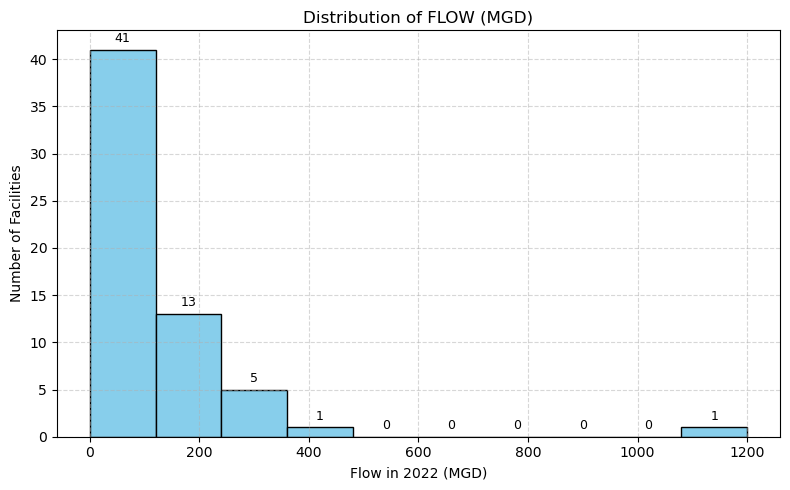

In [35]:
# Create histogram and capture the counts and bin edges
plt.figure(figsize=(8, 5))
counts, bins, patches = plt.hist(df_plot['FLOW_2022_MGD_FINAL'], bins=10, color='skyblue', edgecolor='black')

# Add labels above bars
for count, bin_left, bin_right in zip(counts, bins[:-1], bins[1:]):
    bin_center = (bin_left + bin_right) / 2
    plt.text(bin_center, count + 0.5, f'{int(count)}', ha='center', va='bottom', fontsize=9)

# Labels and styling
plt.xlabel('Flow in 2022 (MGD)')
plt.ylabel('Number of Facilities')
plt.title('Distribution of FLOW (MGD)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

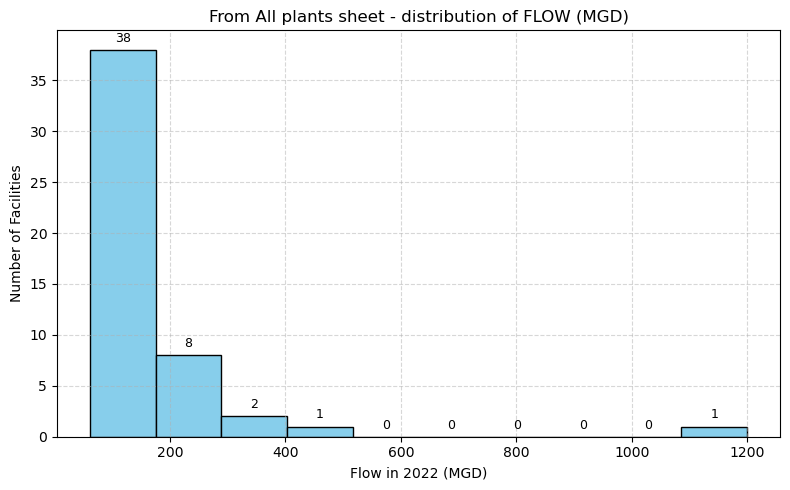

In [34]:
# If I select the top 50 by flow from all WWTP data how the distribution looks like?
df_top50 = df_all_plants.query("FACILITY_TYPE == 'Treatment Plant' and FLOW_2022_MGD_FINAL > 0") \
                        .nlargest(50, 'FLOW_2022_MGD_FINAL')

plt.figure(figsize=(8, 5))
counts, bins, patches = plt.hist(df_top50['FLOW_2022_MGD_FINAL'], bins=10, color='skyblue', edgecolor='black')

# Add labels above bars
for count, bin_left, bin_right in zip(counts, bins[:-1], bins[1:]):
    bin_center = (bin_left + bin_right) / 2
    plt.text(bin_center, count + 0.5, f'{int(count)}', ha='center', va='bottom', fontsize=9)

# Labels and styling
plt.xlabel('Flow in 2022 (MGD)')
plt.ylabel('Number of Facilities')
plt.title('From All plants sheet - distribution of FLOW (MGD)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [10]:
# merge facility level TT assignments per Abbadi et al to top 50 selected WWTPs

df_sel_TT = pd.merge(df_select_plants, df_SI_C, left_on='CWNS_ID', right_on='CWNS code').reset_index(drop=True)
df_sel_TT.head()

,FACILITY_ID,CWNS_ID,FLOW_2022_MGD_FINAL,FACILITY_NAME,INFRASTRUCTURE_TYPE,LATITUDE,LONGITUDE,CITY,STATE_CODE,AUTHORITY_NAME,...,N2O [kg CO2-eq/day],CO2 [kg CO2-eq/day],electricity [kg CO2-eq/day],onsite natural gas [kg CO2-eq/day],upstream natural gas [kg CO2-eq/day],landfill CH4 [kg CO2-eq/day],land application N2O [kg CO2-eq/day],total onsite emission [kg CO2-eq/day],total emission [kg CO2-eq/day],treatment train
0,1113995,17000721001,1200.0,"MWRDGC, Stickney Treatment Plant",Wastewater,41.813900,-87.770400,Cicero,IL,MWRDGC,...,1.029981e+06,95392.377360,185963.235669,0.0,0.0,0.000000,52535.457534,2.906532e+06,3.092495e+06,['*E1']
1,1114001,17000721009,450.0,"MWRDGC, CALUMET WRP, MWRDGC",Wastewater,41.662500,-87.610000,Chicago,IL,MWRDGC,...,3.862430e+05,35772.141510,69736.213376,0.0,0.0,0.000000,8473.631507,1.078722e+06,1.148458e+06,['*E1']
2,1220315,36002001011,317.0,New York (C) - Newtown Creek WPCP,Wastewater,40.731400,-73.946400,New York,NY,NYCDEP,...,2.720867e+05,25199.486353,95897.138647,0.0,0.0,3741.965589,4767.189041,7.624399e+05,8.583370e+05,['*E1']
3,1092422,25000128001,315.0,MWRA Deer Island WWTF,Wastewater,42.350500,-70.956900,Boston,MA,Mass. Water Resources Authority,...,2.299876e+05,25040.499057,190722.128205,0.0,0.0,0.000000,16021.680822,7.248132e+05,9.155354e+05,['F1e']
4,3612343,48000000409,285.0,Austin 5 Year CIP - Citywide Wastewater,Wastewater,30.274486,-97.740297,Austin,TX,Austin,...,2.446206e+05,22655.689623,295338.523797,0.0,0.0,17835.818026,22722.474113,7.183824e+05,1.013721e+06,['*E1']


In [11]:
# Assign TT assignments to different columns
TT_expand =  pd.DataFrame ( df_sel_TT['treatment train'].str.strip("[]").str.replace("'", "").str.split(', ').tolist() ).fillna('')
TT_expand.columns = [f'TT_{i+1}' for i in TT_expand.columns]
df_sel_TT = pd.concat([df_sel_TT, TT_expand], axis=1)

df_sel_TT.head()

,FACILITY_ID,CWNS_ID,FLOW_2022_MGD_FINAL,FACILITY_NAME,INFRASTRUCTURE_TYPE,LATITUDE,LONGITUDE,CITY,STATE_CODE,AUTHORITY_NAME,...,upstream natural gas [kg CO2-eq/day],landfill CH4 [kg CO2-eq/day],land application N2O [kg CO2-eq/day],total onsite emission [kg CO2-eq/day],total emission [kg CO2-eq/day],treatment train,TT_1,TT_2,TT_3,TT_4
0,1113995,17000721001,1200.0,"MWRDGC, Stickney Treatment Plant",Wastewater,41.813900,-87.770400,Cicero,IL,MWRDGC,...,0.0,0.000000,52535.457534,2.906532e+06,3.092495e+06,['*E1'],*E1,,,
1,1114001,17000721009,450.0,"MWRDGC, CALUMET WRP, MWRDGC",Wastewater,41.662500,-87.610000,Chicago,IL,MWRDGC,...,0.0,0.000000,8473.631507,1.078722e+06,1.148458e+06,['*E1'],*E1,,,
2,1220315,36002001011,317.0,New York (C) - Newtown Creek WPCP,Wastewater,40.731400,-73.946400,New York,NY,NYCDEP,...,0.0,3741.965589,4767.189041,7.624399e+05,8.583370e+05,['*E1'],*E1,,,
3,1092422,25000128001,315.0,MWRA Deer Island WWTF,Wastewater,42.350500,-70.956900,Boston,MA,Mass. Water Resources Authority,...,0.0,0.000000,16021.680822,7.248132e+05,9.155354e+05,['F1e'],F1e,,,
4,3612343,48000000409,285.0,Austin 5 Year CIP - Citywide Wastewater,Wastewater,30.274486,-97.740297,Austin,TX,Austin,...,0.0,17835.818026,22722.474113,7.183824e+05,1.013721e+06,['*E1'],*E1,,,


In [12]:
# Summarize count of TTs

# Select TT columns and replace empty strings with NaN
TT_cols = ['TT_1', 'TT_2', 'TT_3', 'TT_4']
df_tt = df_sel_TT[TT_cols].replace('', np.nan)

# Melt into long format: one TT per row, along with its source column
df_long = df_tt.melt(var_name='TT_col', value_name='TT').dropna()

# Count how often each TT appears in each TT_X column
counts = df_long.groupby(['TT', 'TT_col']).size().unstack(fill_value=0)

# Rename columns like TT_1 → n_TT_1
counts.columns = [f'n_{col}' for col in counts.columns]

# Add total count across all TT_X columns
counts['n_TT'] = counts.sum(axis=1)

# Reset index to get 'TT' as a column
unique_TT_df = counts.reset_index()

if (write_output):
    unique_TT_df.to_csv(path_out + '/' + 'unique_TT.csv', index=False)

unique_TT_df.head()

,TT,n_TT_1,n_TT_2,n_TT_3,n_TT_4,n_TT
0,*A1,2,0,0,0,2
1,*A1e,7,0,0,0,7
2,*A4,2,0,0,0,2
3,*A5,1,1,0,0,2
4,*A6,0,1,0,0,1


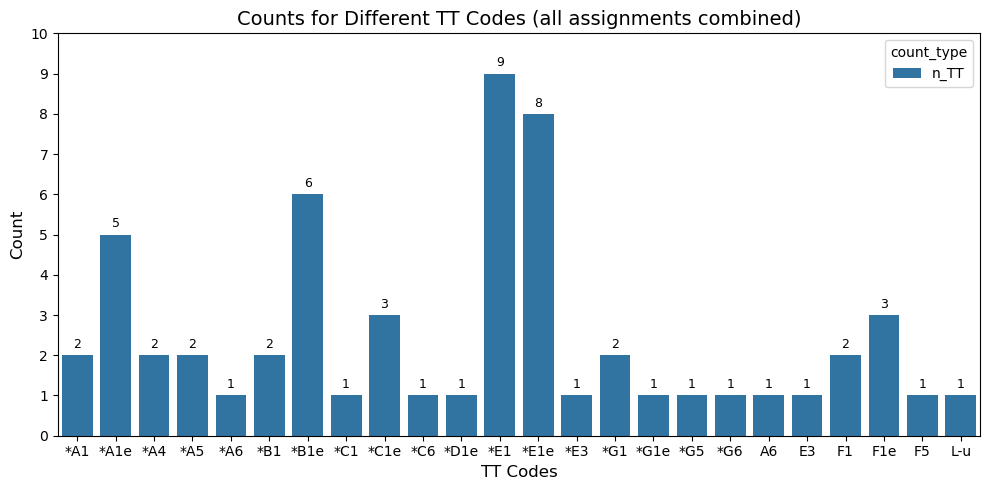

In [44]:
# Plot counts for TTs (all assignments combined)

# Melt the DataFrame to "long" format for Seaborn
df_melted = unique_TT_df.melt(id_vars=['TT'], value_vars=[
    #'n_TT_1', 
    #'n_TT_2', 
    #'n_TT_3', 
    #'n_TT_4', 
    'n_TT'], 
                    var_name='count_type', value_name='count')

# Create the bar plot using Seaborn
plt.figure(figsize=(10, 5))
ax = sns.barplot(x='TT', y='count', hue='count_type', data=df_melted,
            order=sorted(df_melted['TT'].unique())  # alphabetical order
            )

# Show labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)

# Set y-ticks with step of 1, and starting from 0 to max+1
y_max = df_melted['count'].max()
plt.yticks(np.arange(0, y_max + 2, 1))  # +2 so it includes the last tick

# Adding title and labels
plt.title('Counts for Different TT Codes (all assignments combined)', fontsize=14)
plt.xlabel('TT Codes', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

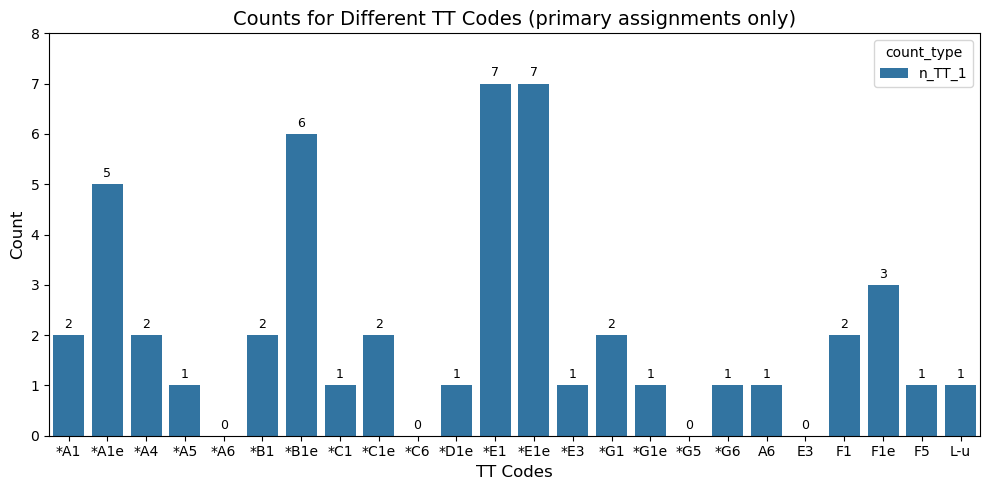

In [45]:
# Plot counts for TTs (for TT Codes_1 only)

# Melt the DataFrame to "long" format for Seaborn
df_melted = unique_TT_df.melt(id_vars=['TT'], value_vars=[
    'n_TT_1', 
    #'n_TT_2', 
    #'n_TT_3', 
    #'n_TT_4', 
    #'n_TT'
    ], 
                    var_name='count_type', value_name='count')

# Create the bar plot using Seaborn
plt.figure(figsize=(10, 5))
ax = sns.barplot(x='TT', y='count', hue='count_type', data=df_melted,
            order=sorted(df_melted['TT'].unique())  # alphabetical order
            )

# Show labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)

# Set y-ticks with step of 1, and starting from 0 to max+1
y_max = df_melted['count'].max()
plt.yticks(np.arange(0, y_max + 2, 1))  # +2 so it includes the last tick

# Adding title and labels
plt.title('Counts for Different TT Codes (primary assignments only)', fontsize=14)
plt.xlabel('TT Codes', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

In [46]:
# Summarize flow by TT

# Select TT columns and replace empty strings with NaN
TT_cols = ['TT_1', 'TT_2', 'TT_3', 'TT_4']
df_tt = df_sel_TT[TT_cols].replace('', np.nan)

# Also select the flow column
flow_col = 'FLOW_2022_MGD_FINAL'
df_tt[flow_col] = df_sel_TT[flow_col]

# Melt TT columns into long format
df_long = df_tt.melt(id_vars=[flow_col], var_name='TT_col', value_name='TT').dropna(subset=['TT'])

# Group by TT and TT_col and sum the flow
flow_sums = df_long.groupby(['TT', 'TT_col'])[flow_col].sum().unstack(fill_value=0)

# Rename columns to indicate sums
flow_sums.columns = [f'sum_{col}' for col in flow_sums.columns]

# Add total sum across all TT columns
flow_sums['sum_TT'] = flow_sums.sum(axis=1)

# Reset index to get TT as a column
unique_TT_flow_df = flow_sums.reset_index()

if write_output:
    unique_TT_flow_df.to_csv(path_out + '/' + 'unique_TT_flow.csv', index=False)

unique_TT_flow_df.head()


,TT,sum_TT_1,sum_TT_2,sum_TT_3,sum_TT_4,sum_TT
0,*A1,182.0,0.0,0.0,0.0,182.0
1,*A1e,845.4,0.0,0.0,0.0,845.4
2,*A4,200.0,0.0,0.0,0.0,200.0
3,*A5,125.0,120.0,0.0,0.0,245.0
4,*A6,0.0,250.0,0.0,0.0,250.0


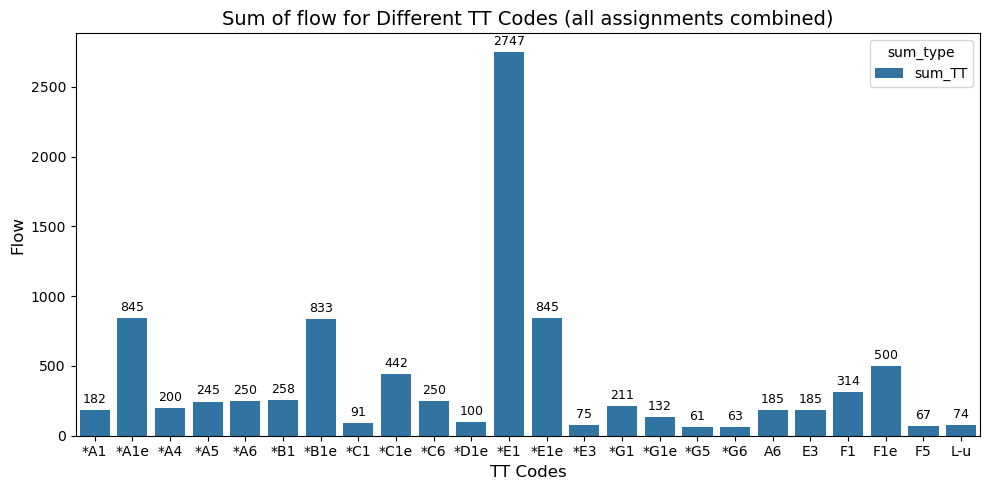

In [47]:
# Plot flow for TTs (all assignments combined)

# Melt the DataFrame to "long" format for Seaborn
df_melted = unique_TT_flow_df.melt(id_vars=['TT'], value_vars=[
    #'sum_TT_1', 
    #'sum_TT_2', 
    #'sum_TT_3', 
    #'sum_TT_4', 
    'sum_TT'], 
                    var_name='sum_type', value_name='sum')

# Create the bar plot using Seaborn
plt.figure(figsize=(10, 5))
ax = sns.barplot(x='TT', y='sum', hue='sum_type', data=df_melted,
            order=sorted(df_melted['TT'].unique())  # alphabetical order
            )

# Show labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)

# Set y-ticks with step of 1, and starting from 0 to max+1
y_max = df_melted['sum'].max()
plt.yticks(np.arange(0, y_max, 500))  

# Adding title and labels
plt.title('Sum of flow for Different TT Codes (all assignments combined)', fontsize=14)
plt.xlabel('TT Codes', fontsize=12)
plt.ylabel('Flow', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

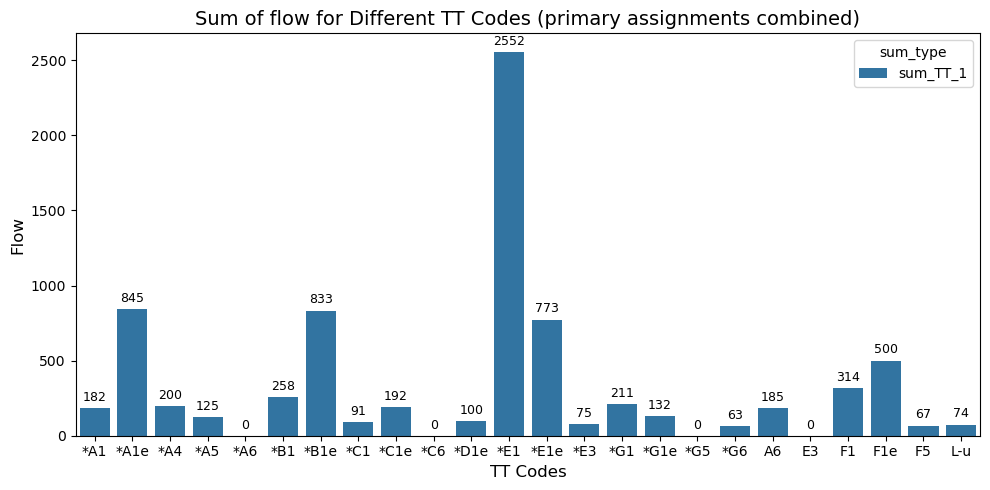

In [48]:
# Plot flow for TTs (for TT Codes_1 only)

# Melt the DataFrame to "long" format for Seaborn
df_melted = unique_TT_flow_df.melt(id_vars=['TT'], value_vars=[
    'sum_TT_1', 
    #'sum_TT_2', 
    #'sum_TT_3', 
    #'sum_TT_4', 
    #'sum_TT'
    ], 
                    var_name='sum_type', value_name='sum')

# Create the bar plot using Seaborn
plt.figure(figsize=(10, 5))
ax = sns.barplot(x='TT', y='sum', hue='sum_type', data=df_melted,
            order=sorted(df_melted['TT'].unique())  # alphabetical order
            )

# Show labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3, fontsize=9)

# Set y-ticks with step of 1, and starting from 0 to max+1
y_max = df_melted['sum'].max()
plt.yticks(np.arange(0, y_max, 500))  

# Adding title and labels
plt.title('Sum of flow for Different TT Codes (primary assignments combined)', fontsize=14)
plt.xlabel('TT Codes', fontsize=12)
plt.ylabel('Flow', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

In [49]:
# Analyze: flow rate vs. energy, flow rate vs. GHG emissions estimates

# Question: Does energy estimates and GHG emission estimates follow a linear trend w.r.t. flow rate?
# Knowing this will help us to make assumption of scale when doing GREET implementation

TT_expand =  pd.DataFrame ( df_SI_C['treatment train'].str.strip("[]").str.replace("'", "").str.split(', ').tolist() ).fillna('')
TT_expand.columns = [f'TT_{i+1}' for i in TT_expand.columns]
df_SI_C_1 = pd.concat([df_SI_C, TT_expand], axis=1)
#print(df_SI_C_1.columns)
df_SI_C_1.head()

,CWNS code,facility,state,city,latitude,longitude,flow [MGD],CH4 [kg CO2-eq/day],N2O [kg CO2-eq/day],CO2 [kg CO2-eq/day],...,landfill CH4 [kg CO2-eq/day],land application N2O [kg CO2-eq/day],total onsite emission [kg CO2-eq/day],total emission [kg CO2-eq/day],treatment train,TT_1,TT_2,TT_3,TT_4,TT_5
0,30000044001,"DODSON, TOWN OF - WWTP",MT,Dodson,48.389200,-108.255600,0.033,11.803866,28.859841,2.623290,...,0.991556,1.263222,45.541775,45.914735,['L-u'],L-u,,,,
1,30000180001,BIGFORK COUNTY WATER & SEWER DIS.,MT,Bigfork,48.063800,-114.083100,0.500,720.259414,90.211347,39.746824,...,0.590448,36.306329,887.114362,892.666543,['*C1'],*C1,,,,
2,28001370001,"UTICA POTW, SOUTH",MS,Utica,32.109092,-90.622721,0.070,25.038503,61.217844,5.564555,...,2.103301,2.679563,96.603765,128.042961,['L-u'],L-u,,,,
3,41000244001,RIDDLE STP,OR,Riddle,42.951900,-123.356600,0.250,106.234033,45.105674,19.873412,...,0.000000,19.013253,199.023247,360.517721,['A3'],A3,,,,
4,47000010001,Adamsville Lagoon,TN,Adamsville,35.225200,-88.405000,0.299,0.000000,310.756508,23.768601,...,8.924729,11.369925,354.819762,512.458248,['L-a'],L-a,,,,


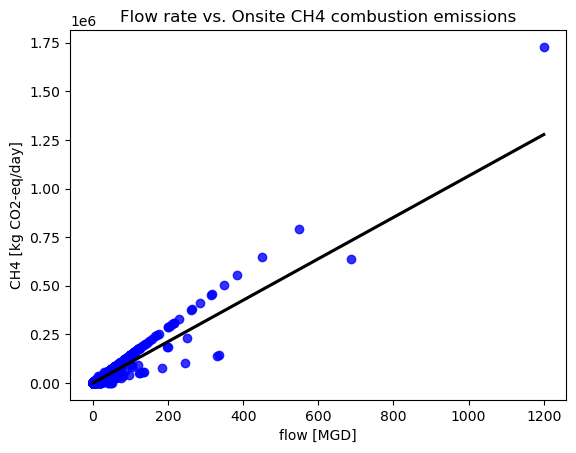

In [50]:
# flow rate vs onsite CH4 combustion emissions for all TTs

# sns.scatterplot(data=df_SI_C_1, x='flow [MGD]', y='CH4 [kg CO2-eq/day]')
sns.regplot(x='flow [MGD]', y='CH4 [kg CO2-eq/day]', data=df_SI_C_1, lowess=True, scatter_kws={'color': 'blue'}, line_kws={'color': 'black'})

plt.title('Flow rate vs. Onsite CH4 combustion emissions')
plt.show()

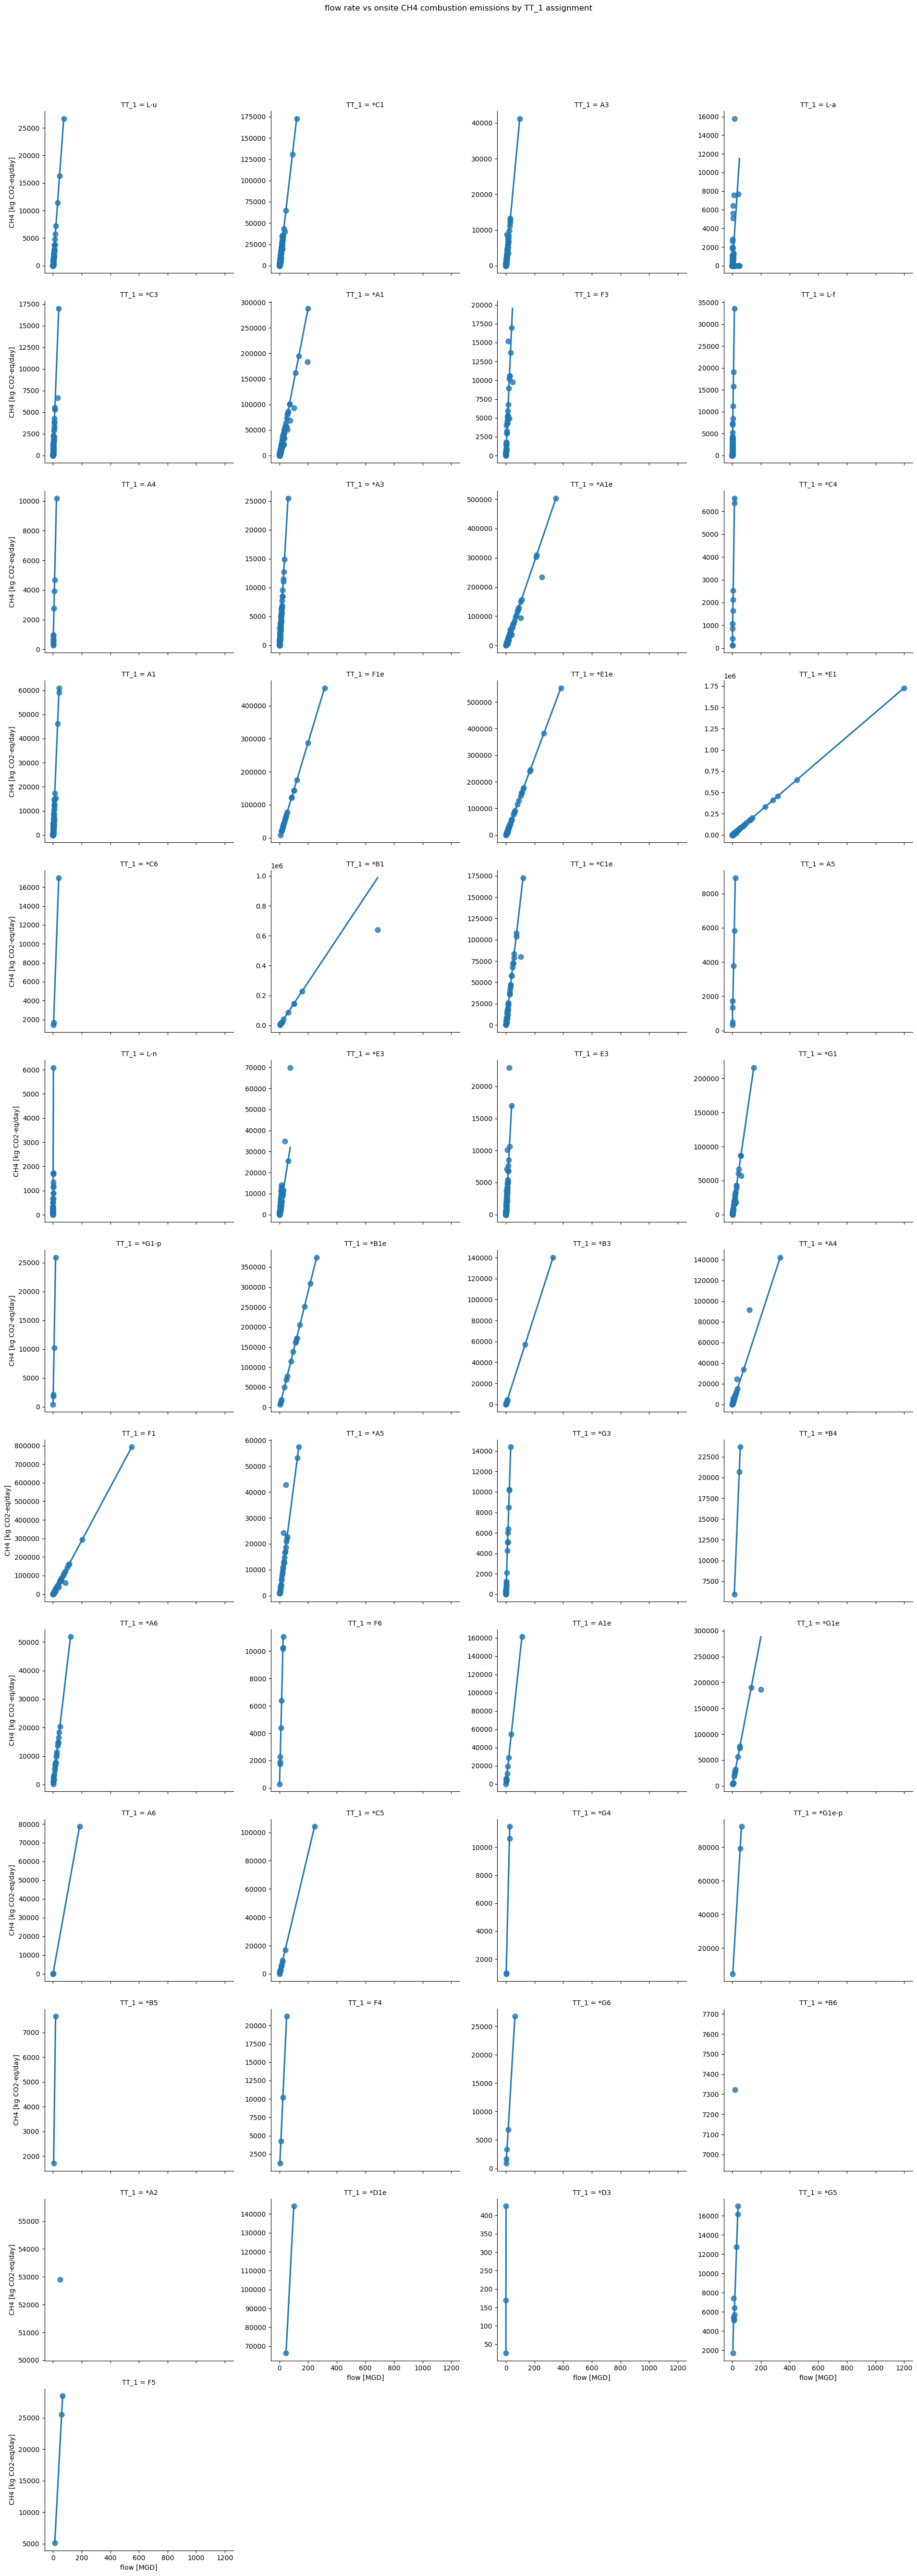

In [51]:
# flow rate vs onsite CH4 combustion emissions by TT_1 assignment

sns.lmplot(
    data=df_SI_C_1,
    x='flow [MGD]',
    y='CH4 [kg CO2-eq/day]',
    col='TT_1',       # Facet by group
    col_wrap=4,
    lowess=True,       # Add smoother fit, change to False for linear fit
    height=4,
    aspect=1.2,
    scatter_kws={'s': 60},
    facet_kws={'sharey': False}, # separate y-axis scales
)

plt.suptitle('flow rate vs onsite CH4 combustion emissions by TT_1 assignment', y=1.03)
plt.tight_layout()
plt.show()

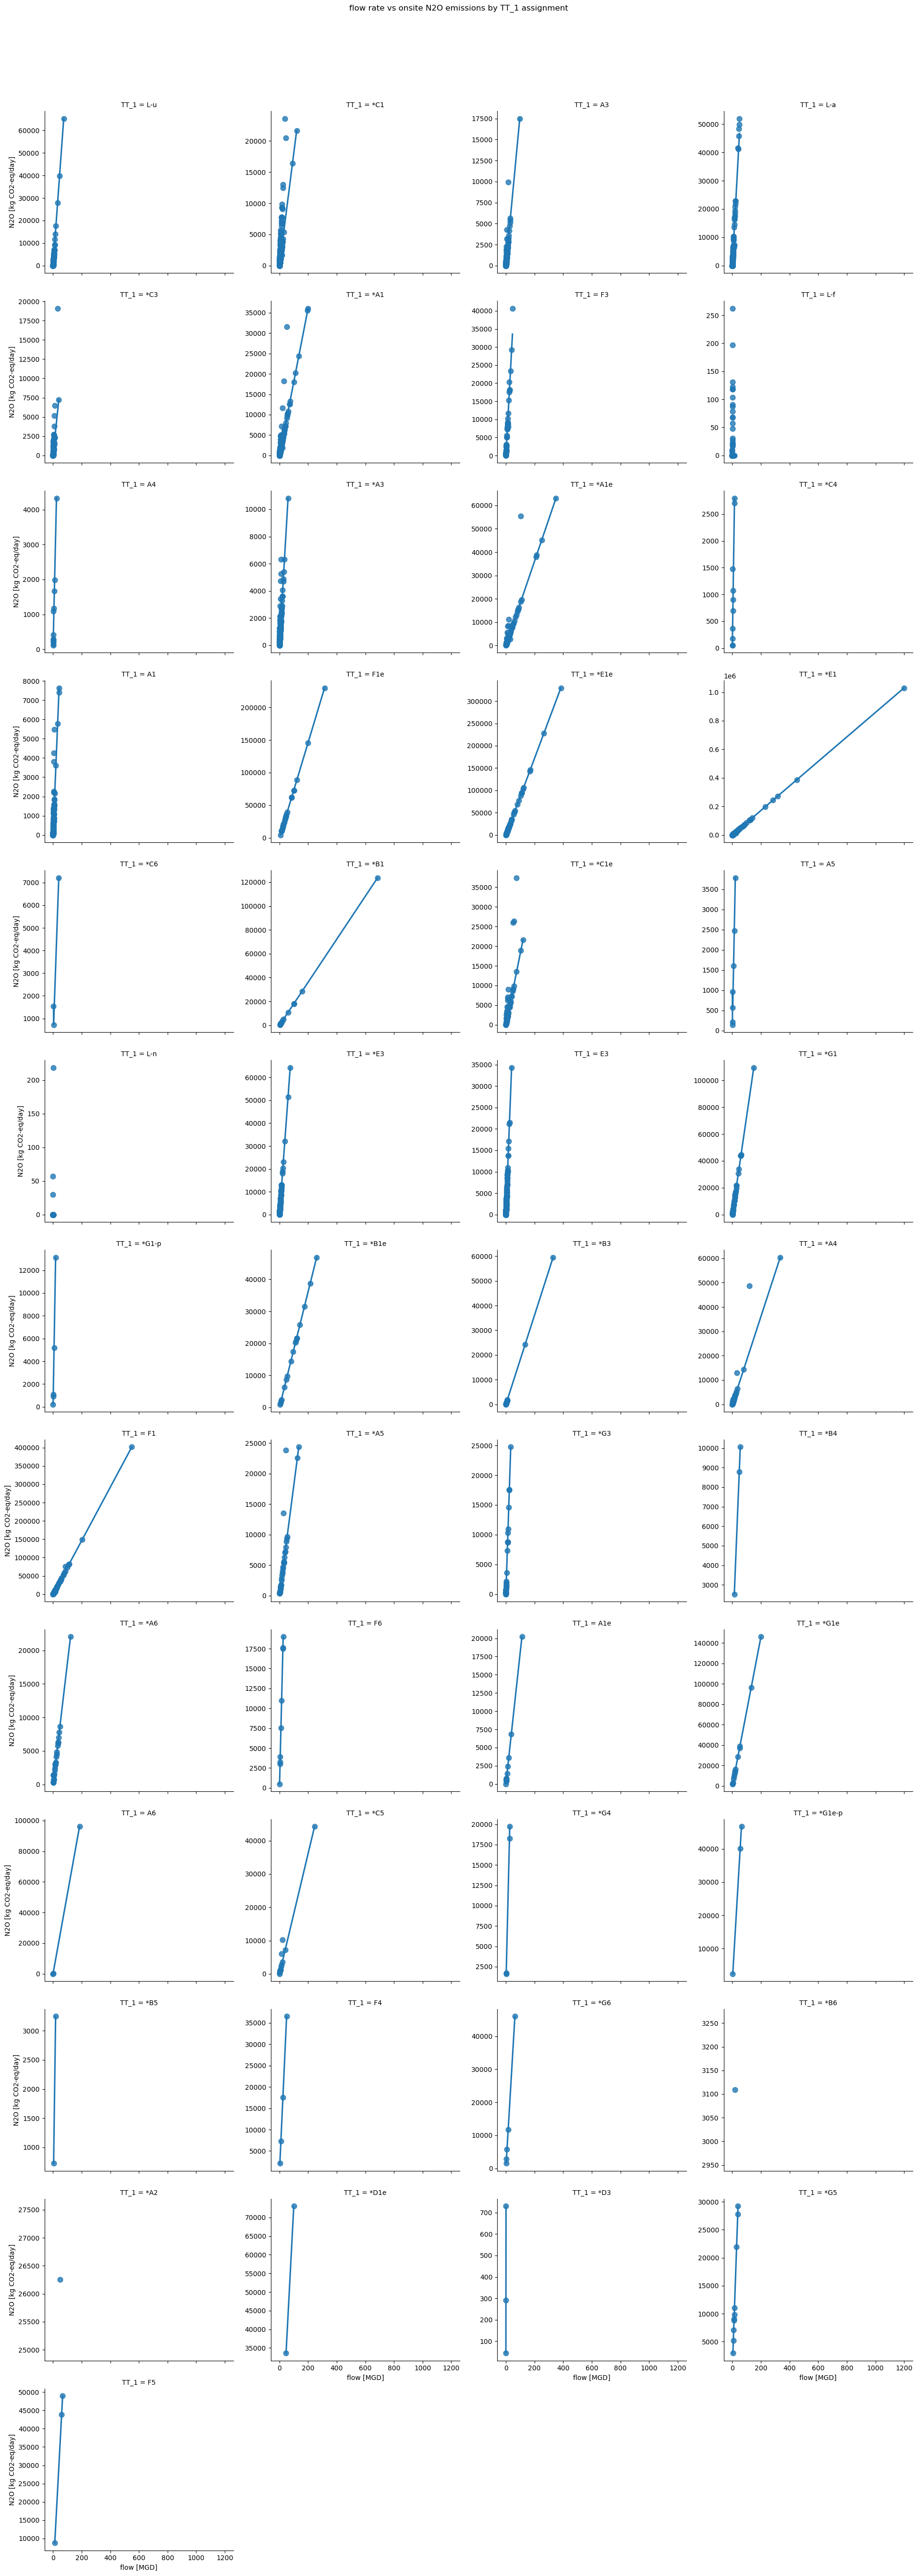

In [52]:
# flow rate vs onsite N2O emissions by TT_1 assignment

sns.lmplot(
    data=df_SI_C_1,
    x='flow [MGD]',
    y='N2O [kg CO2-eq/day]',
    col='TT_1',       # Facet by group
    col_wrap=4,
    lowess=True,       # Add smoother fit, change to False for linear fit
    height=4,
    aspect=1.2,
    scatter_kws={'s': 60},
    facet_kws={'sharey': False}, # separate y-axis scales
)

plt.suptitle('flow rate vs onsite N2O emissions by TT_1 assignment', y=1.03)
plt.tight_layout()
plt.show()

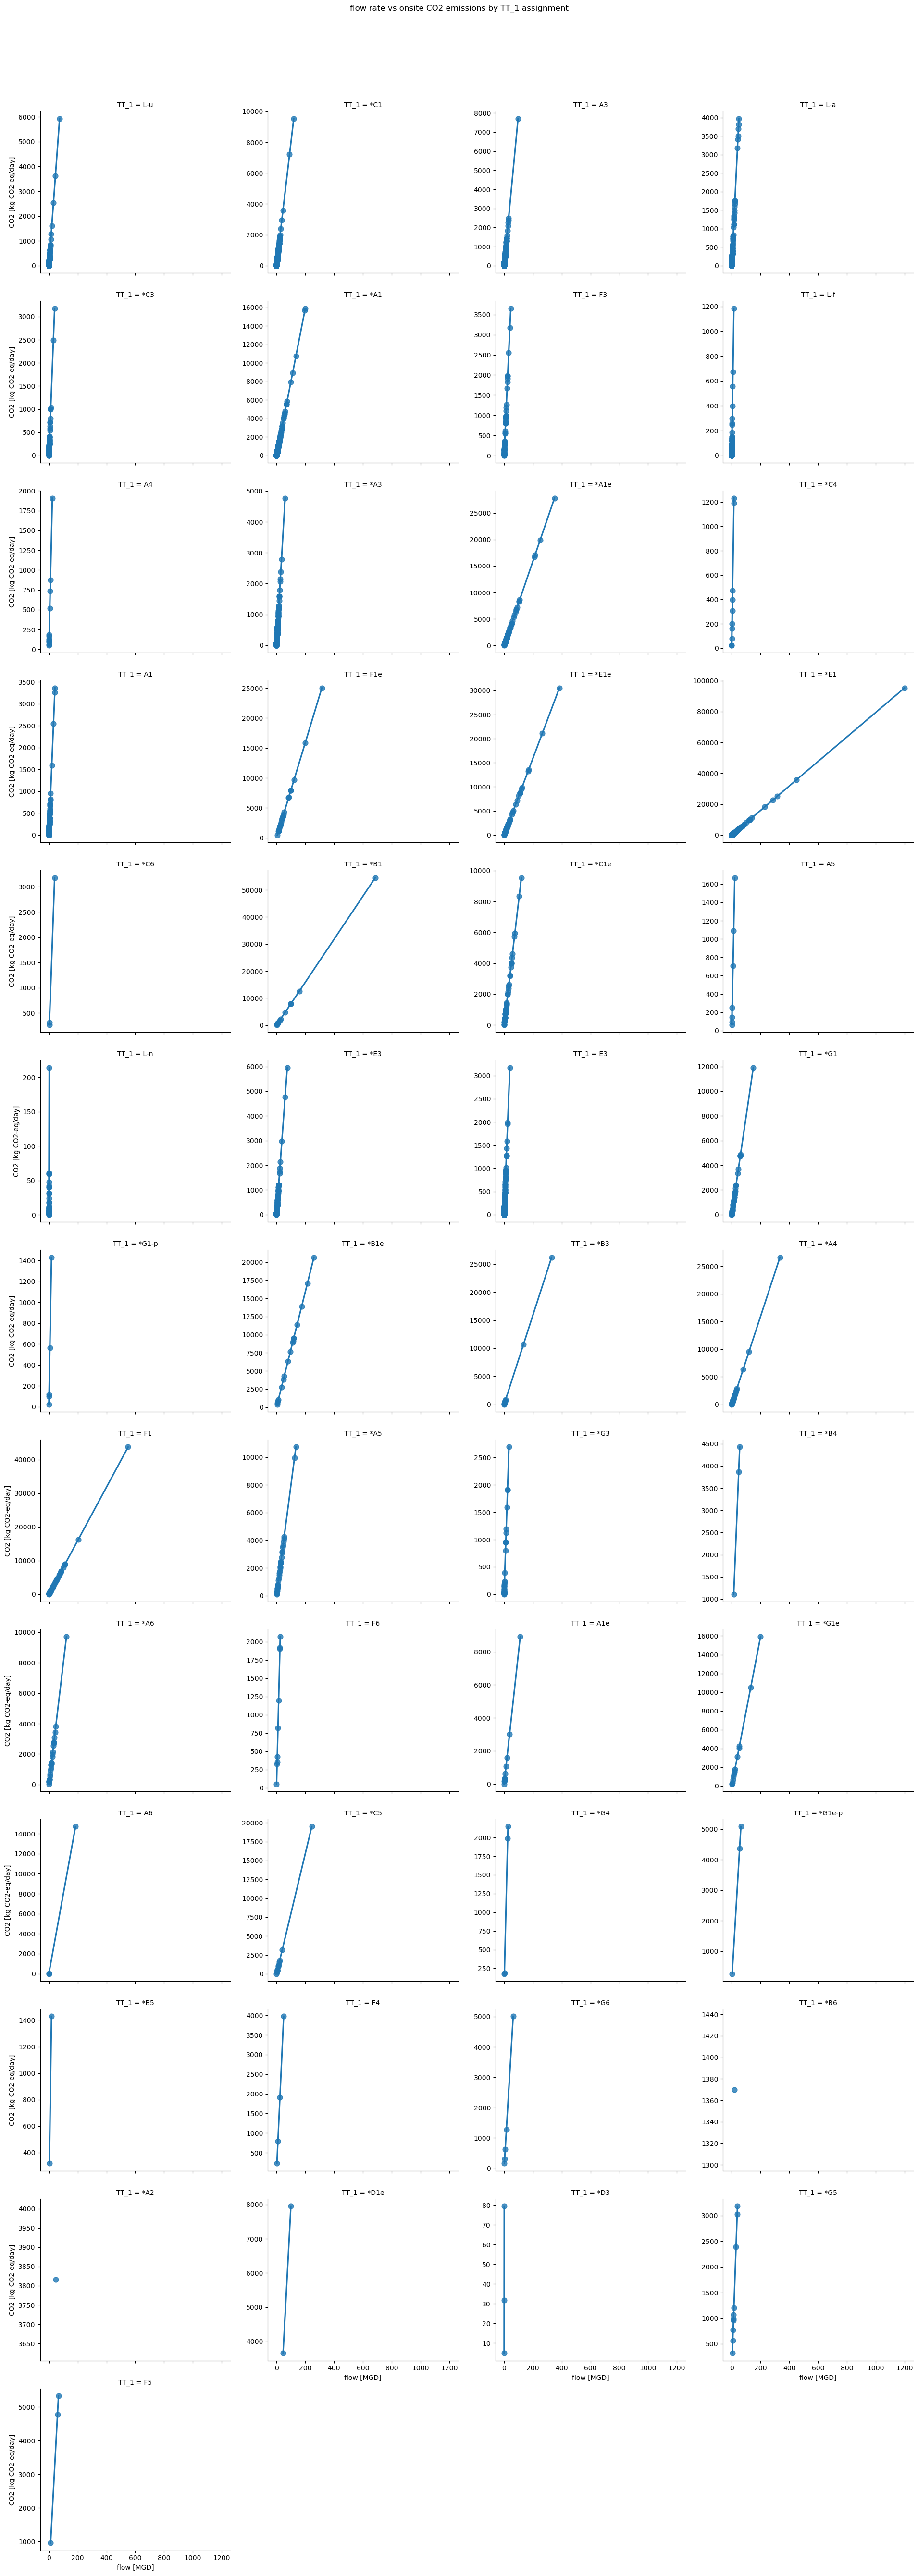

In [53]:
# flow rate vs onsite CO2 emissions by TT_1 assignment

sns.lmplot(
    data=df_SI_C_1,
    x='flow [MGD]',
    y='CO2 [kg CO2-eq/day]',
    col='TT_1',       # Facet by group
    col_wrap=4,
    lowess=True,       # Add smoother fit, change to False for linear fit
    height=4,
    aspect=1.2,
    scatter_kws={'s': 60},
    facet_kws={'sharey': False}, # separate y-axis scales
)

plt.suptitle('flow rate vs onsite CO2 emissions by TT_1 assignment', y=1.03)
plt.tight_layout()
plt.show()

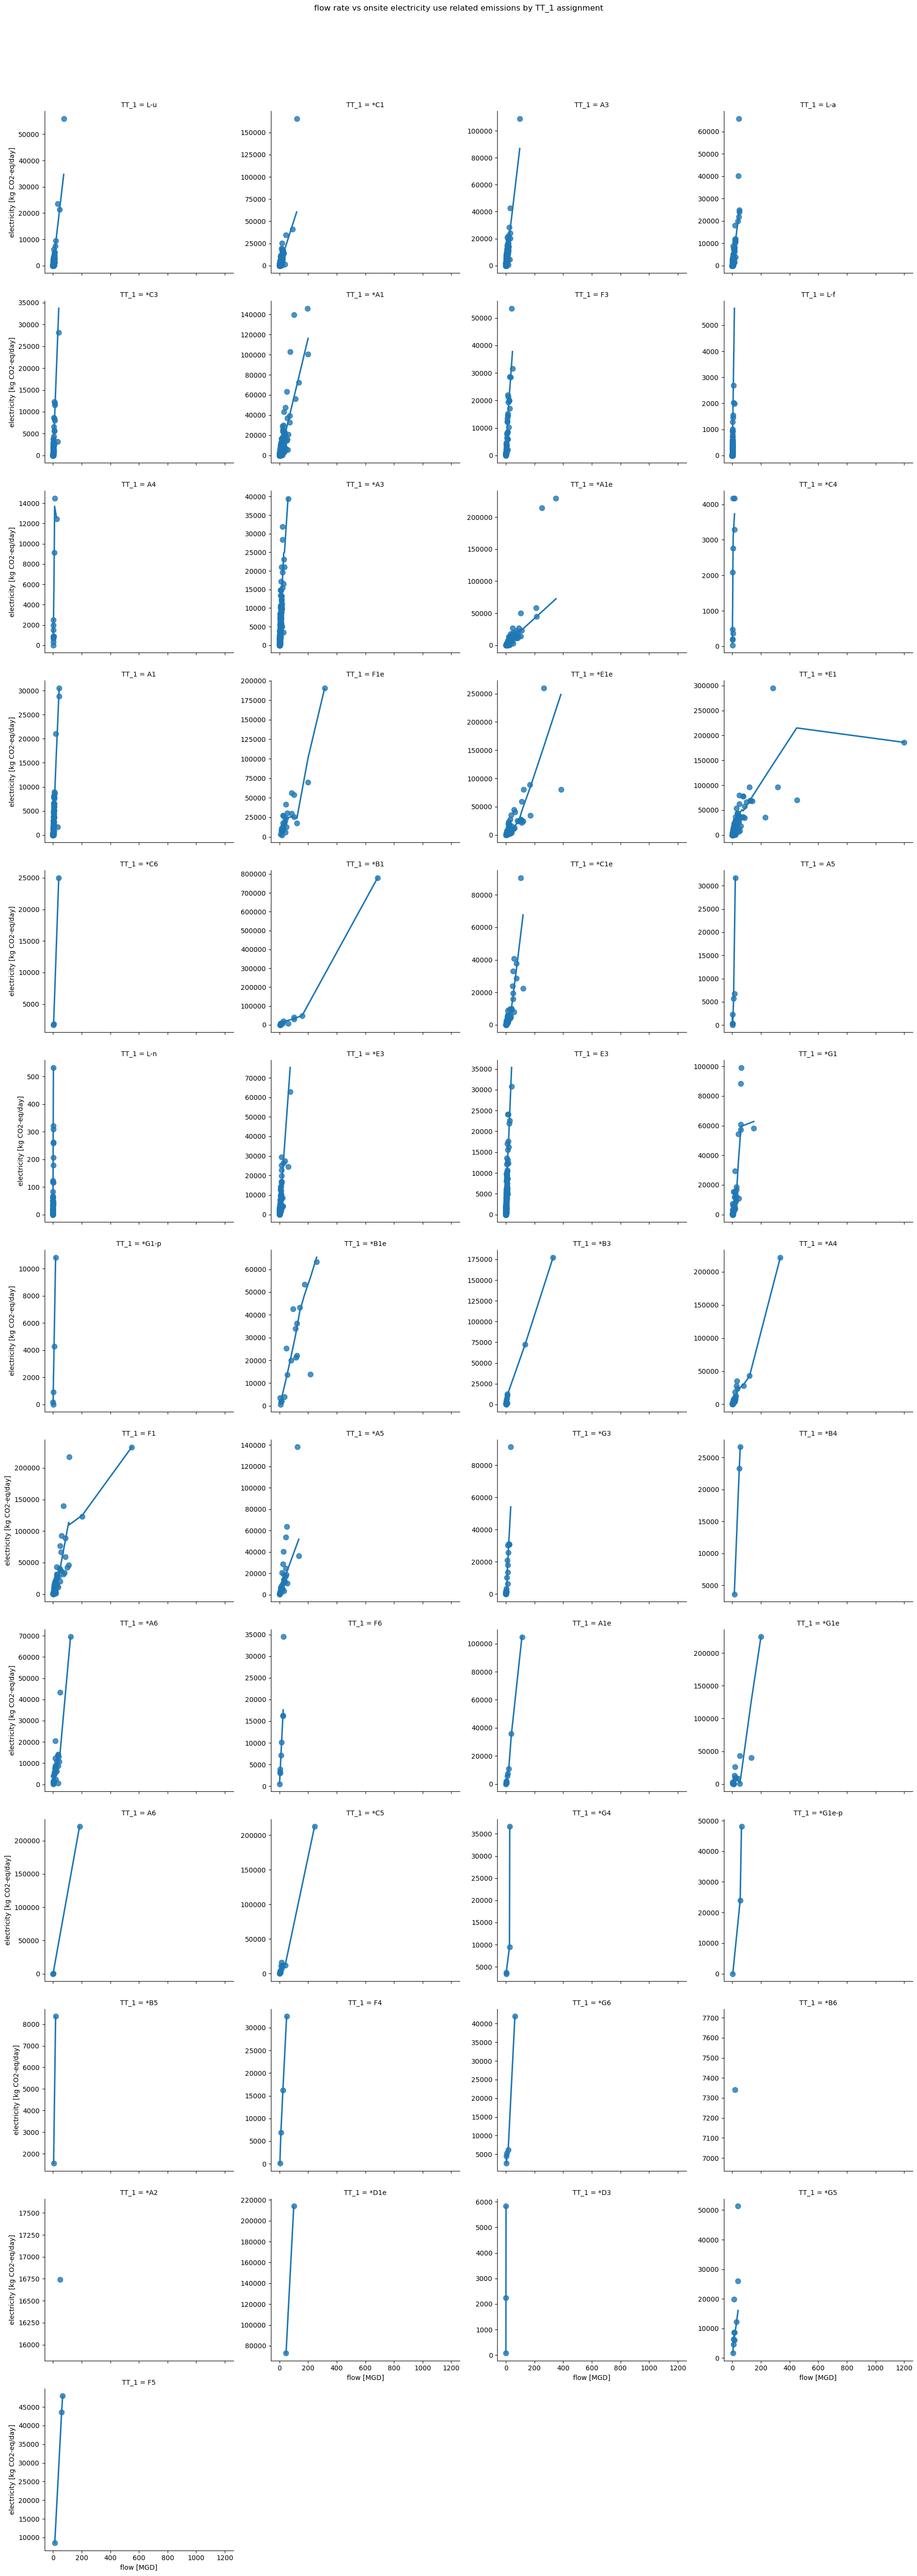

In [54]:
# flow rate vs onsite electricity use related emissions by TT_1 assignment

sns.lmplot(
    data=df_SI_C_1,
    x='flow [MGD]',
    y='electricity [kg CO2-eq/day]',
    col='TT_1',       # Facet by group
    col_wrap=4,
    lowess=True,       # Add smoother fit, change to False for linear fit
    height=4,
    aspect=1.2,
    scatter_kws={'s': 60},
    facet_kws={'sharey': False}, # separate y-axis scales
)

plt.suptitle('flow rate vs onsite electricity use related emissions by TT_1 assignment', y=1.03)
plt.tight_layout()
plt.show()

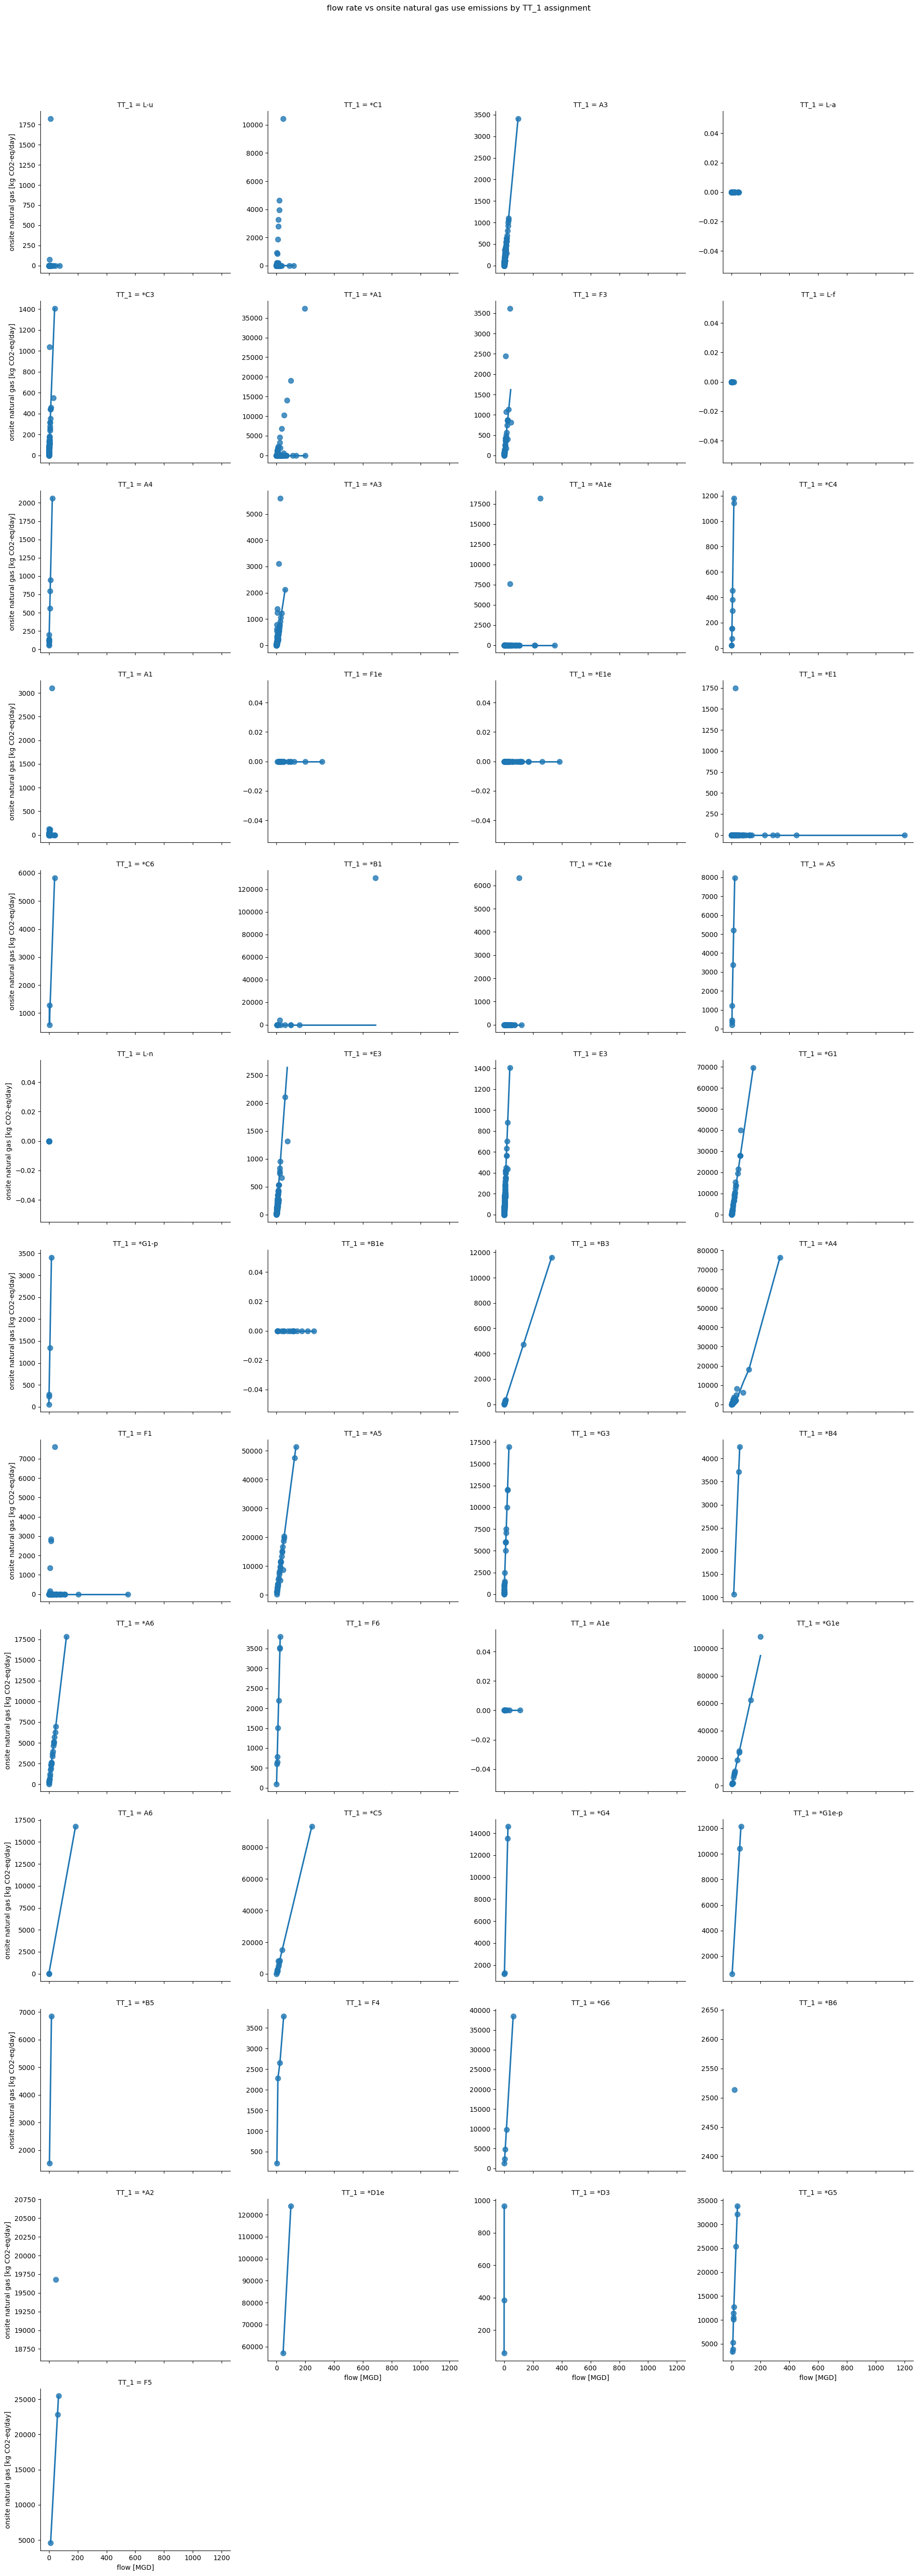

In [55]:
# flow rate vs onsite natural gas use emissions by TT_1 assignment

sns.lmplot(
    data=df_SI_C_1,
    x='flow [MGD]',
    y='onsite natural gas [kg CO2-eq/day]',
    col='TT_1',       # Facet by group
    col_wrap=4,
    lowess=True,       # Add smoother fit, change to False for linear fit
    height=4,
    aspect=1.2,
    scatter_kws={'s': 60},
    facet_kws={'sharey': False}, # separate y-axis scales
)

plt.suptitle('flow rate vs onsite natural gas use emissions by TT_1 assignment', y=1.03)
plt.tight_layout()
plt.show()

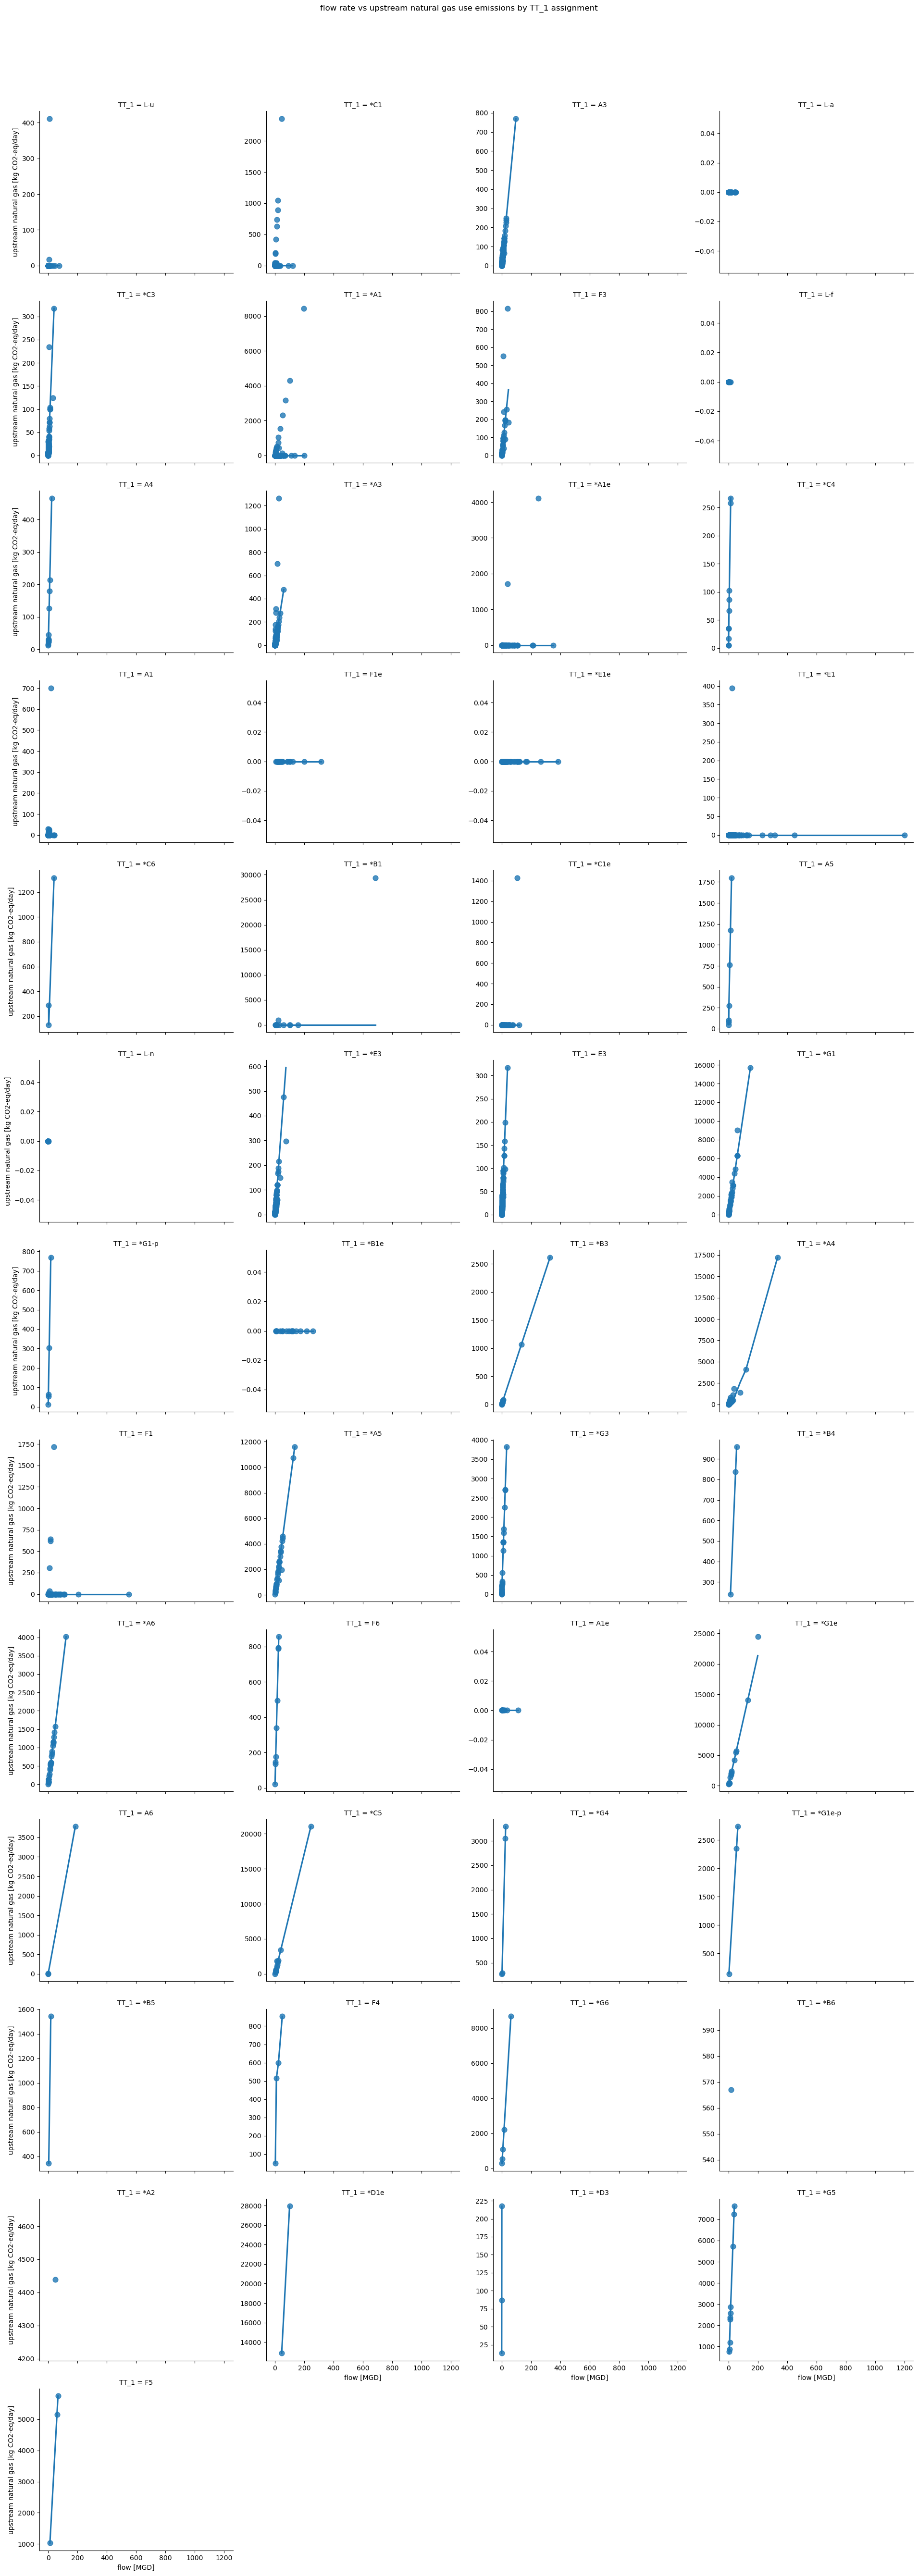

In [56]:
# flow rate vs upstream natural gas use emissions by TT_1 assignment

sns.lmplot(
    data=df_SI_C_1,
    x='flow [MGD]',
    y='upstream natural gas [kg CO2-eq/day]',
    col='TT_1',       # Facet by group
    col_wrap=4,
    lowess=True,       # Add smoother fit, change to False for linear fit
    height=4,
    aspect=1.2,
    scatter_kws={'s': 60},
    facet_kws={'sharey': False}, # separate y-axis scales
)

plt.suptitle('flow rate vs upstream natural gas use emissions by TT_1 assignment', y=1.03)
plt.tight_layout()
plt.show()

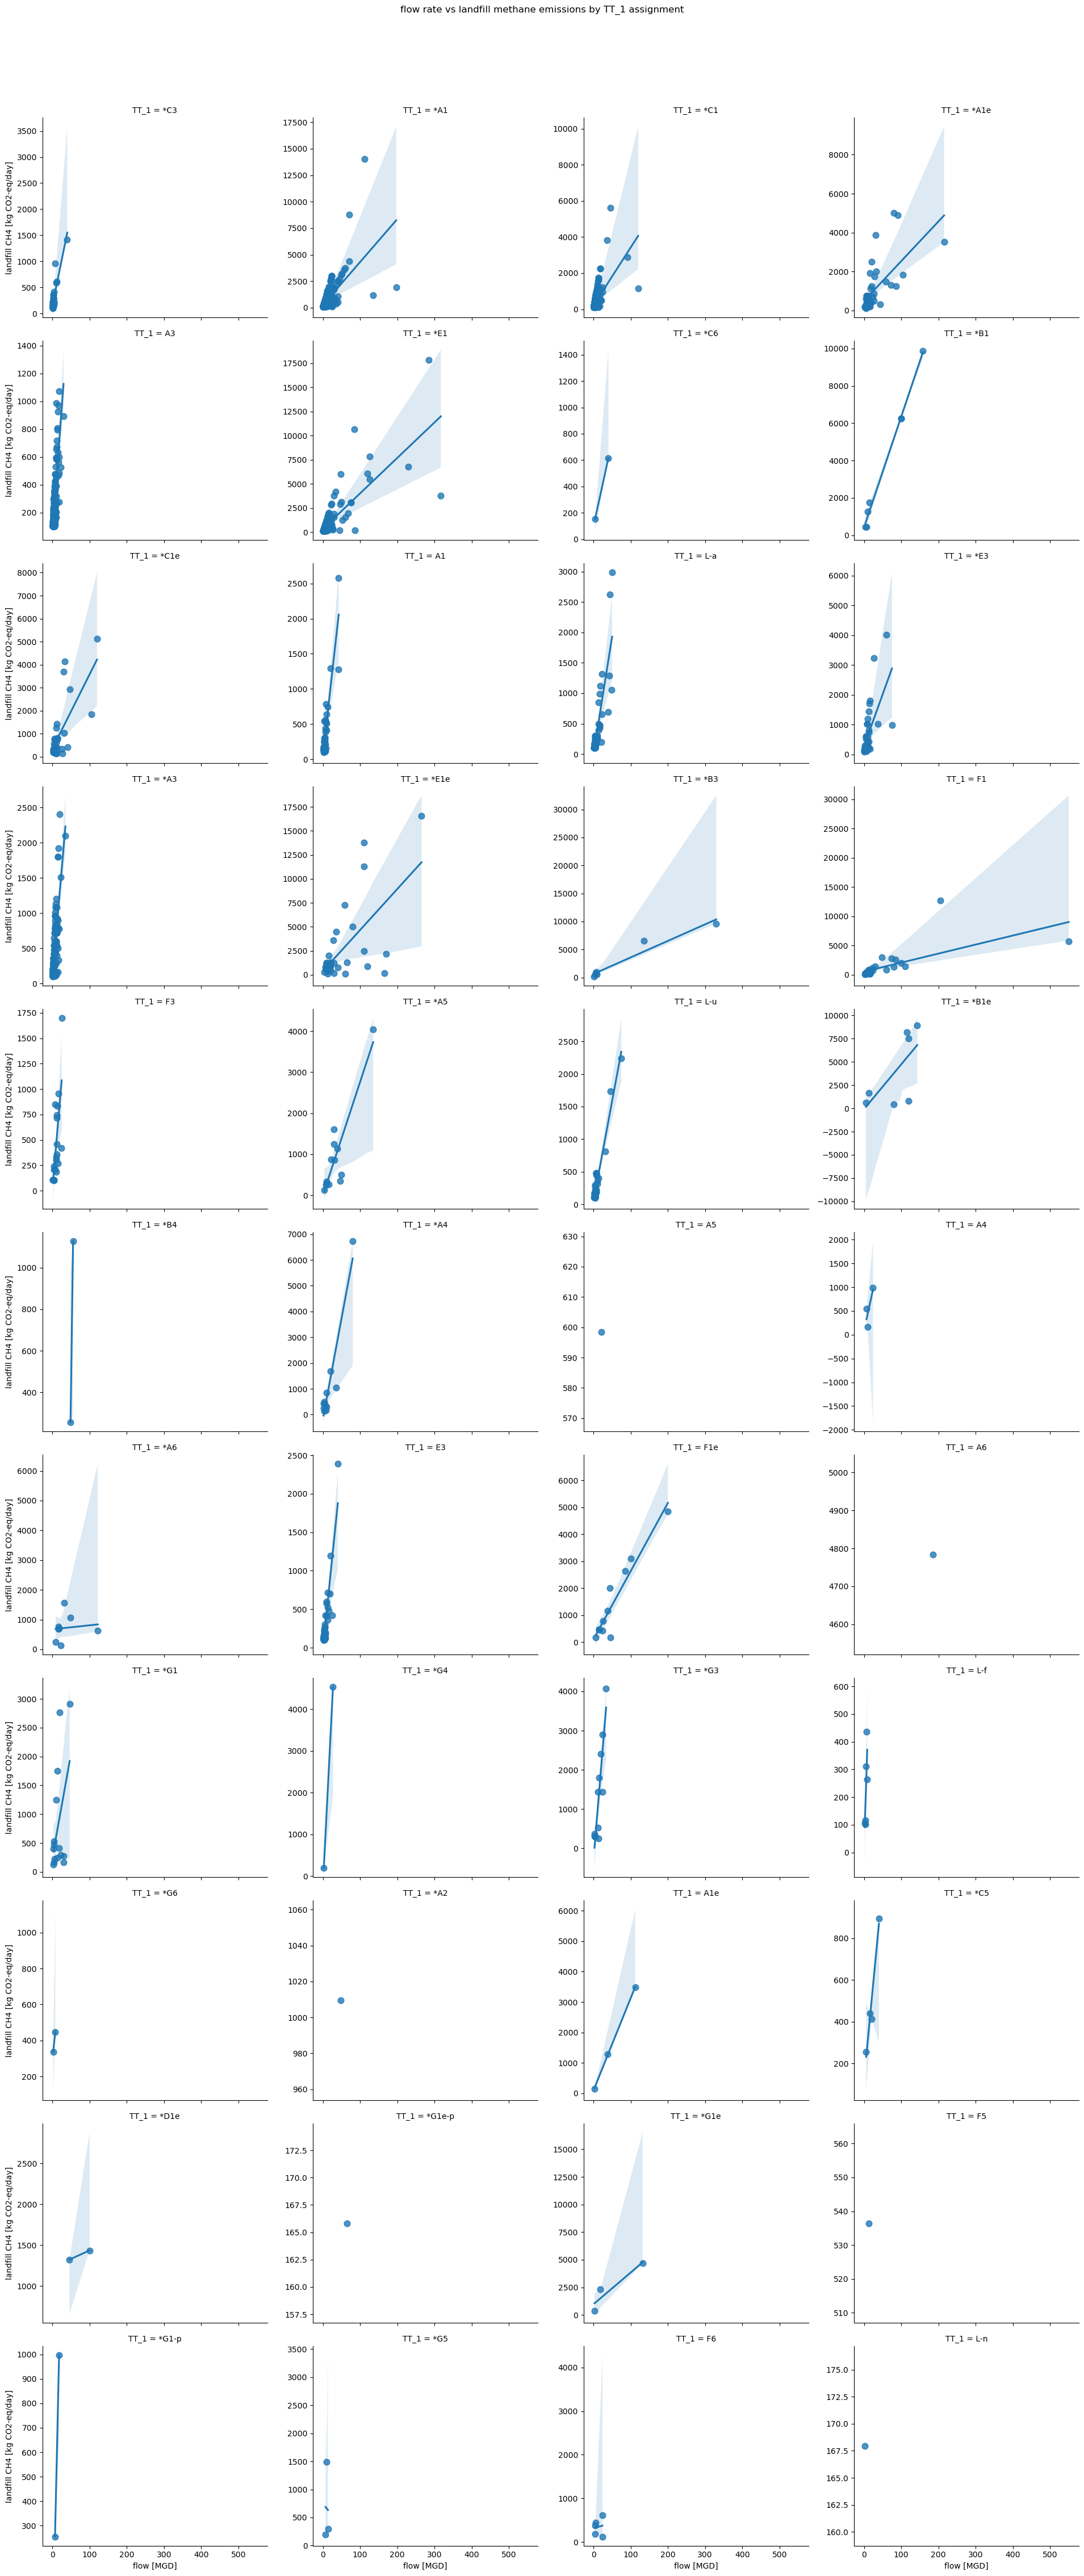

In [57]:
# flow rate vs landfill methane emissions by TT_1 assignment

# Remove plants (with a very low cutoff) to select plants which does have landfill application

df_SI_C_2 = df_SI_C_1[ df_SI_C_1['landfill CH4 [kg CO2-eq/day]'] > 100 ] 

sns.lmplot(
    data=df_SI_C_2,
    x='flow [MGD]',
    y='landfill CH4 [kg CO2-eq/day]',
    col='TT_1',       # Facet by group
    col_wrap=4,
    lowess=False,       # Add smoother fit, change to False for linear fit
    height=4,
    aspect=1.2,
    scatter_kws={'s': 60},
    facet_kws={'sharey': False}, # separate y-axis scales
)

plt.suptitle('flow rate vs landfill methane emissions by TT_1 assignment', y=1.03)
plt.tight_layout()
plt.show()

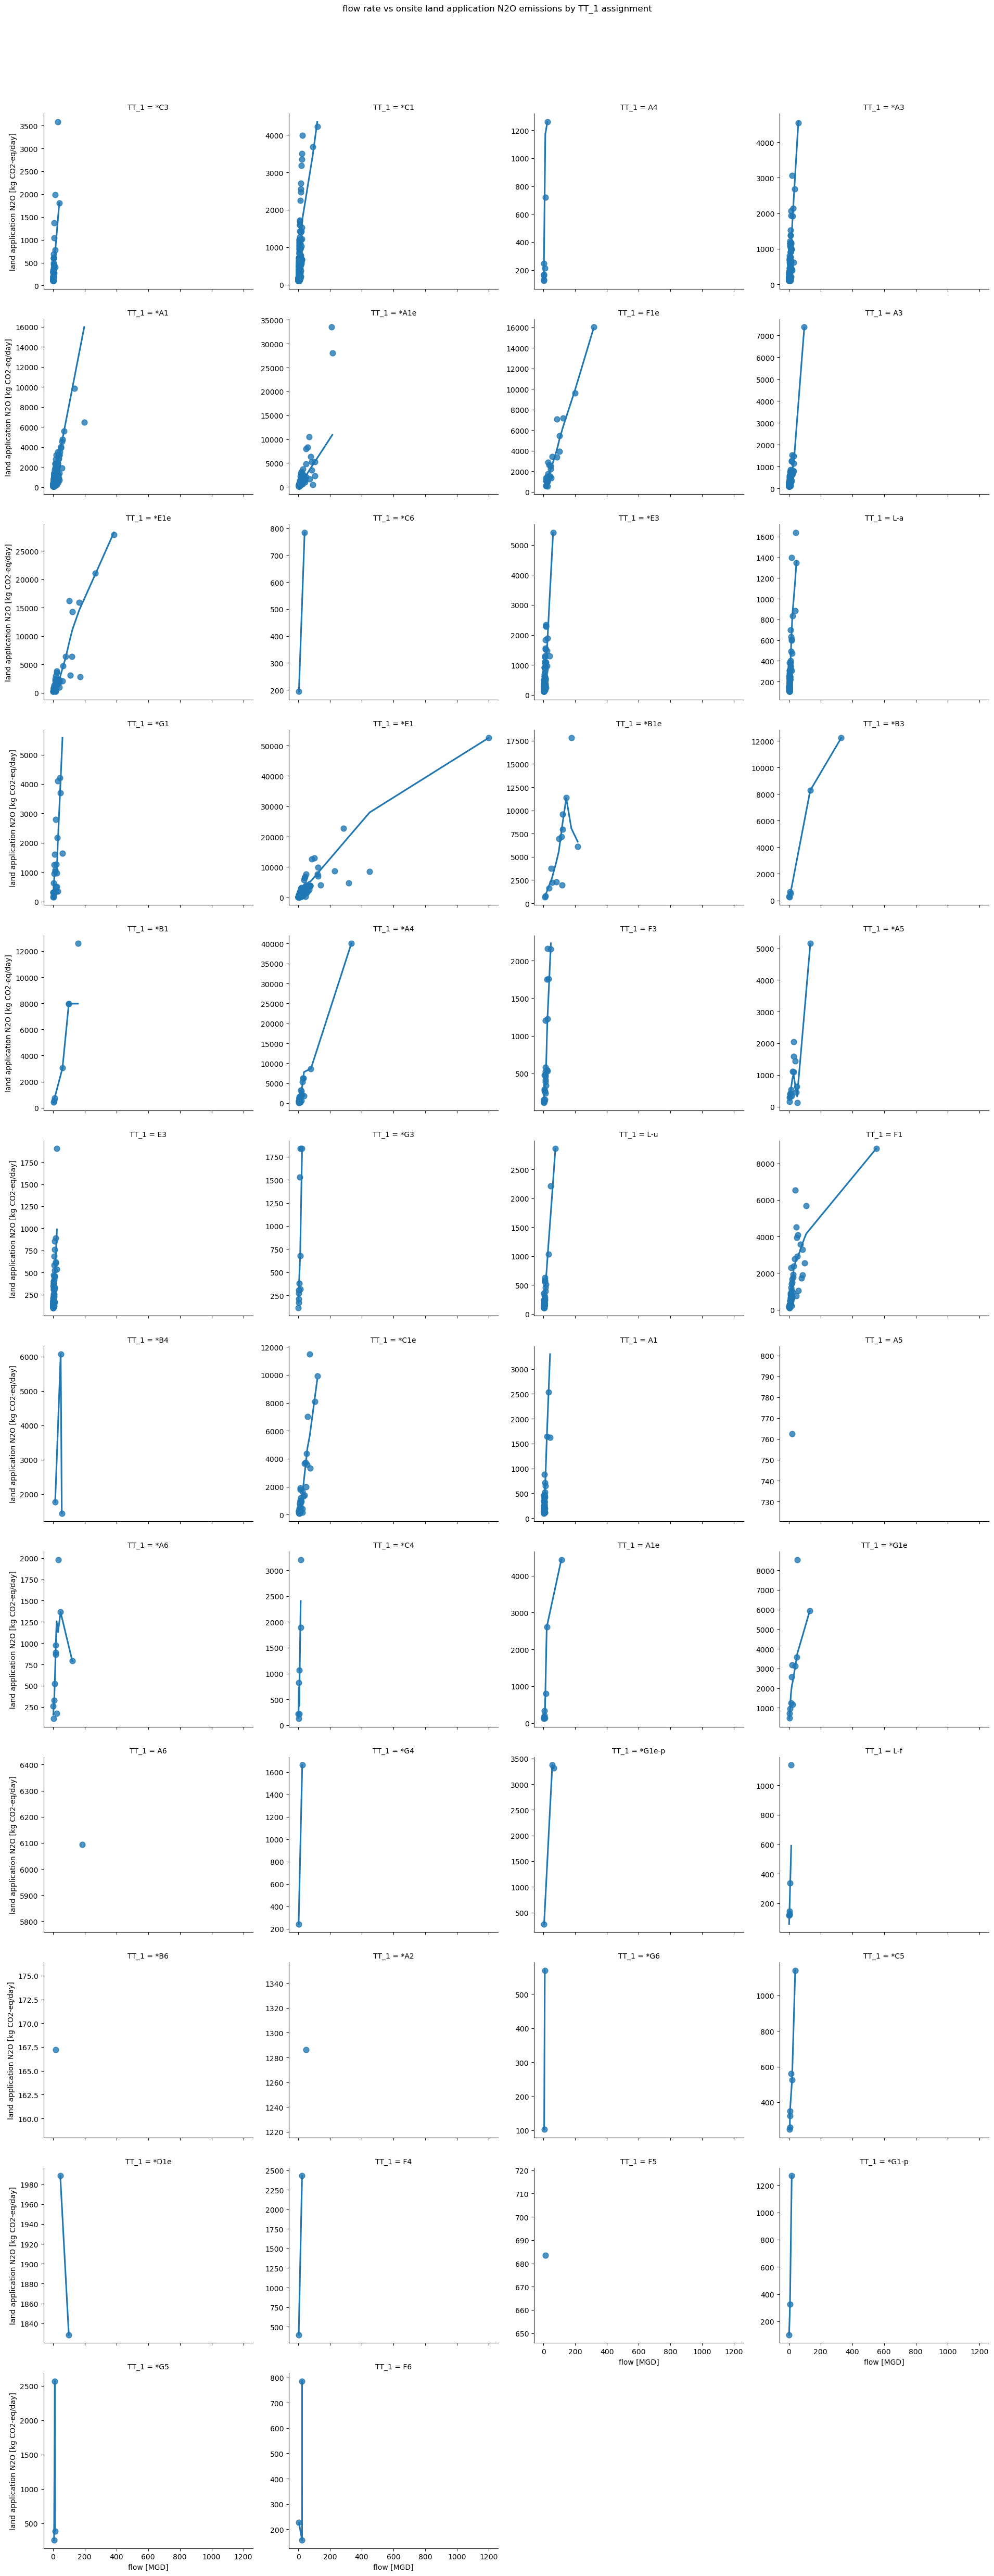

In [58]:
# flow rate vs onsite land application N2O emissions by TT_1 assignment

# Remove plants (with a very low cutoff) to select plants which does have landfill application

df_SI_C_2 = df_SI_C_1[ df_SI_C_1['land application N2O [kg CO2-eq/day]'] > 100 ] 

sns.lmplot(
    data=df_SI_C_2,
    x='flow [MGD]',
    y='land application N2O [kg CO2-eq/day]',
    col='TT_1',       # Facet by group
    col_wrap=4,
    lowess=True,       # Add smoother fit, change to False for linear fit
    height=4,
    aspect=1.2,
    scatter_kws={'s': 60},
    facet_kws={'sharey': False}, # separate y-axis scales
)

plt.suptitle('flow rate vs onsite land application N2O emissions by TT_1 assignment', y=1.03)
plt.tight_layout()
plt.show()

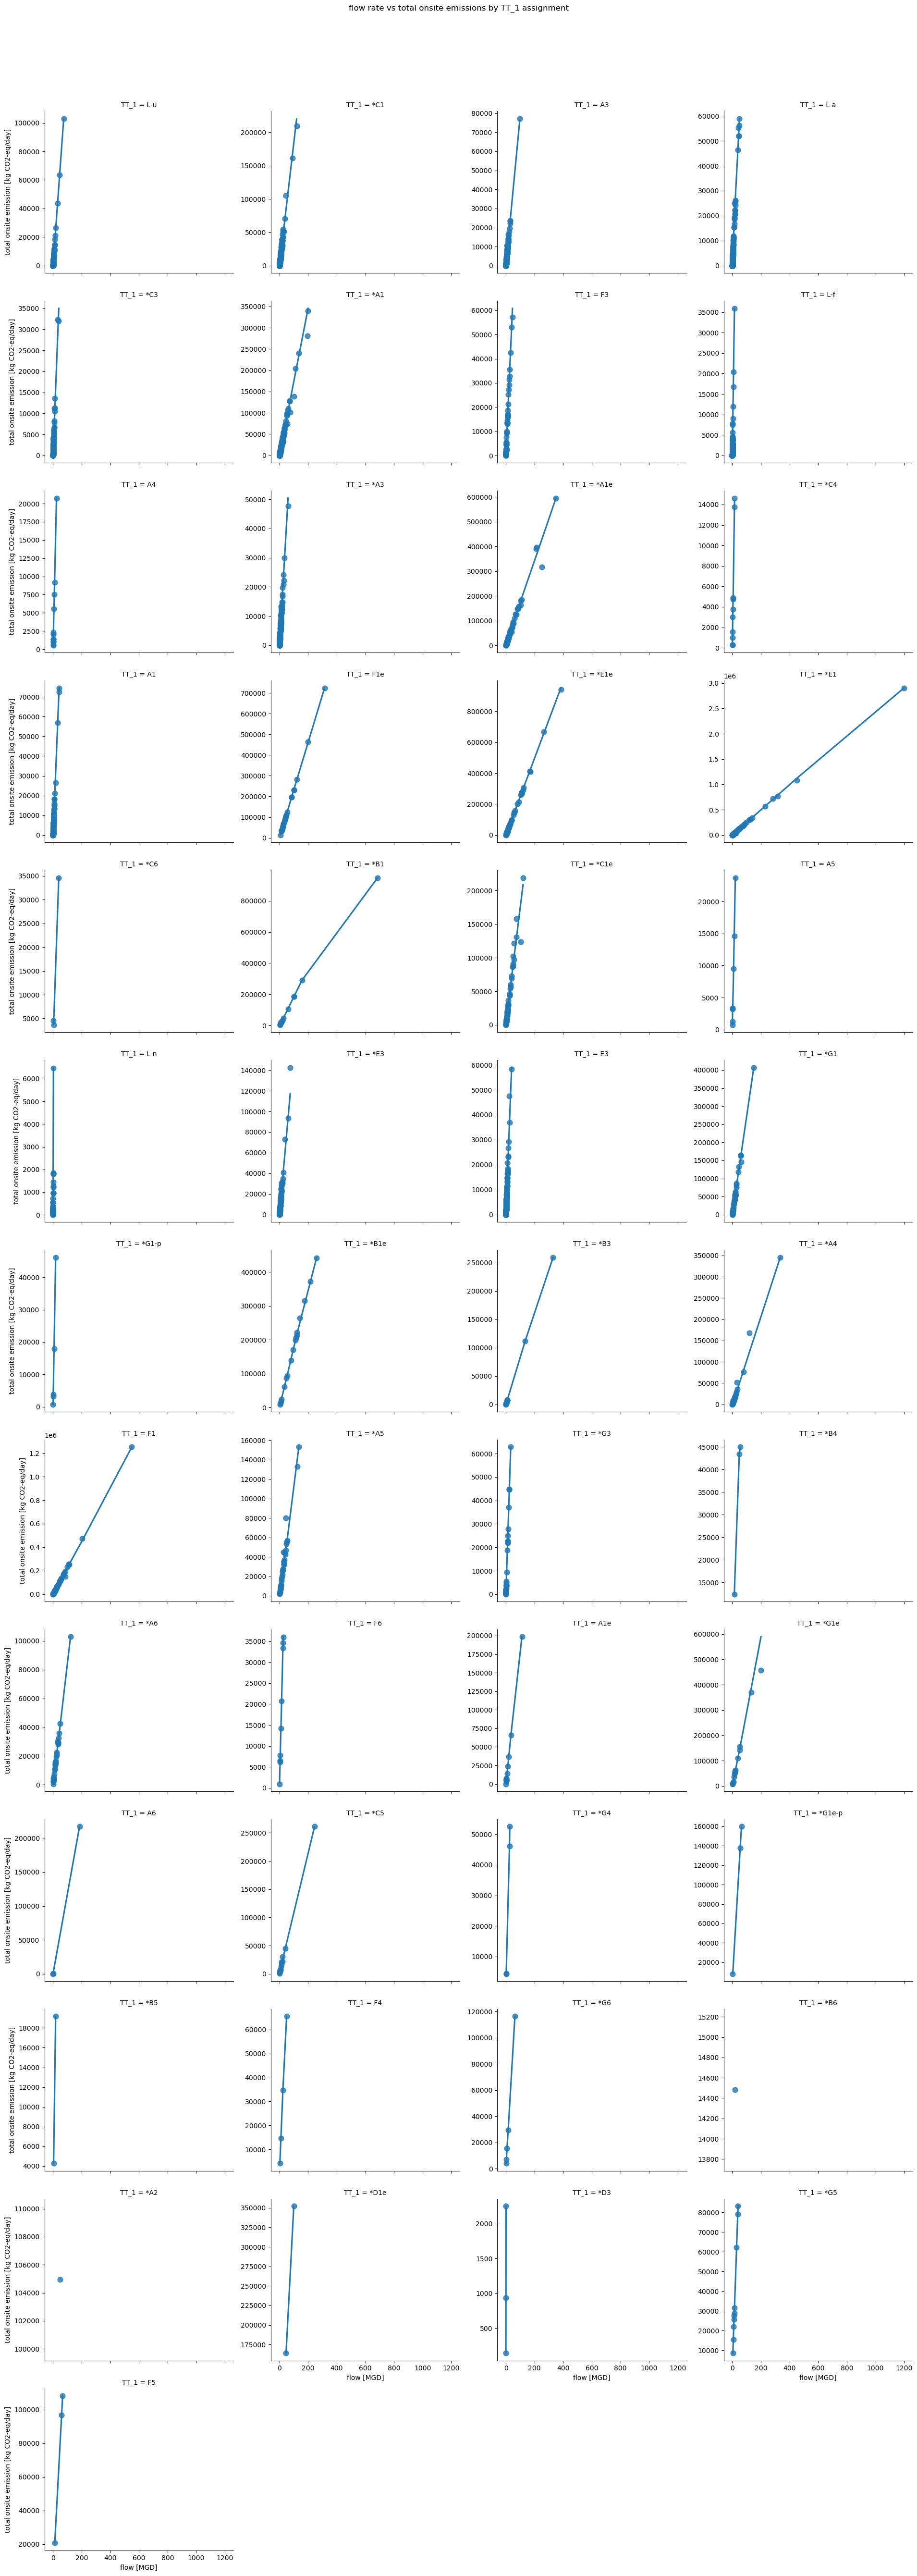

In [59]:
# flow rate vs total onsite emissions by TT_1 assignment

sns.lmplot(
    data=df_SI_C_1,
    x='flow [MGD]',
    y='total onsite emission [kg CO2-eq/day]',
    col='TT_1',       # Facet by group
    col_wrap=4,
    lowess=True,       # Add smoother fit, change to False for linear fit
    height=4,
    aspect=1.2,
    scatter_kws={'s': 60},
    facet_kws={'sharey': False}, # separate y-axis scales
)

plt.suptitle('flow rate vs total onsite emissions by TT_1 assignment', y=1.03)
plt.tight_layout()
plt.show()

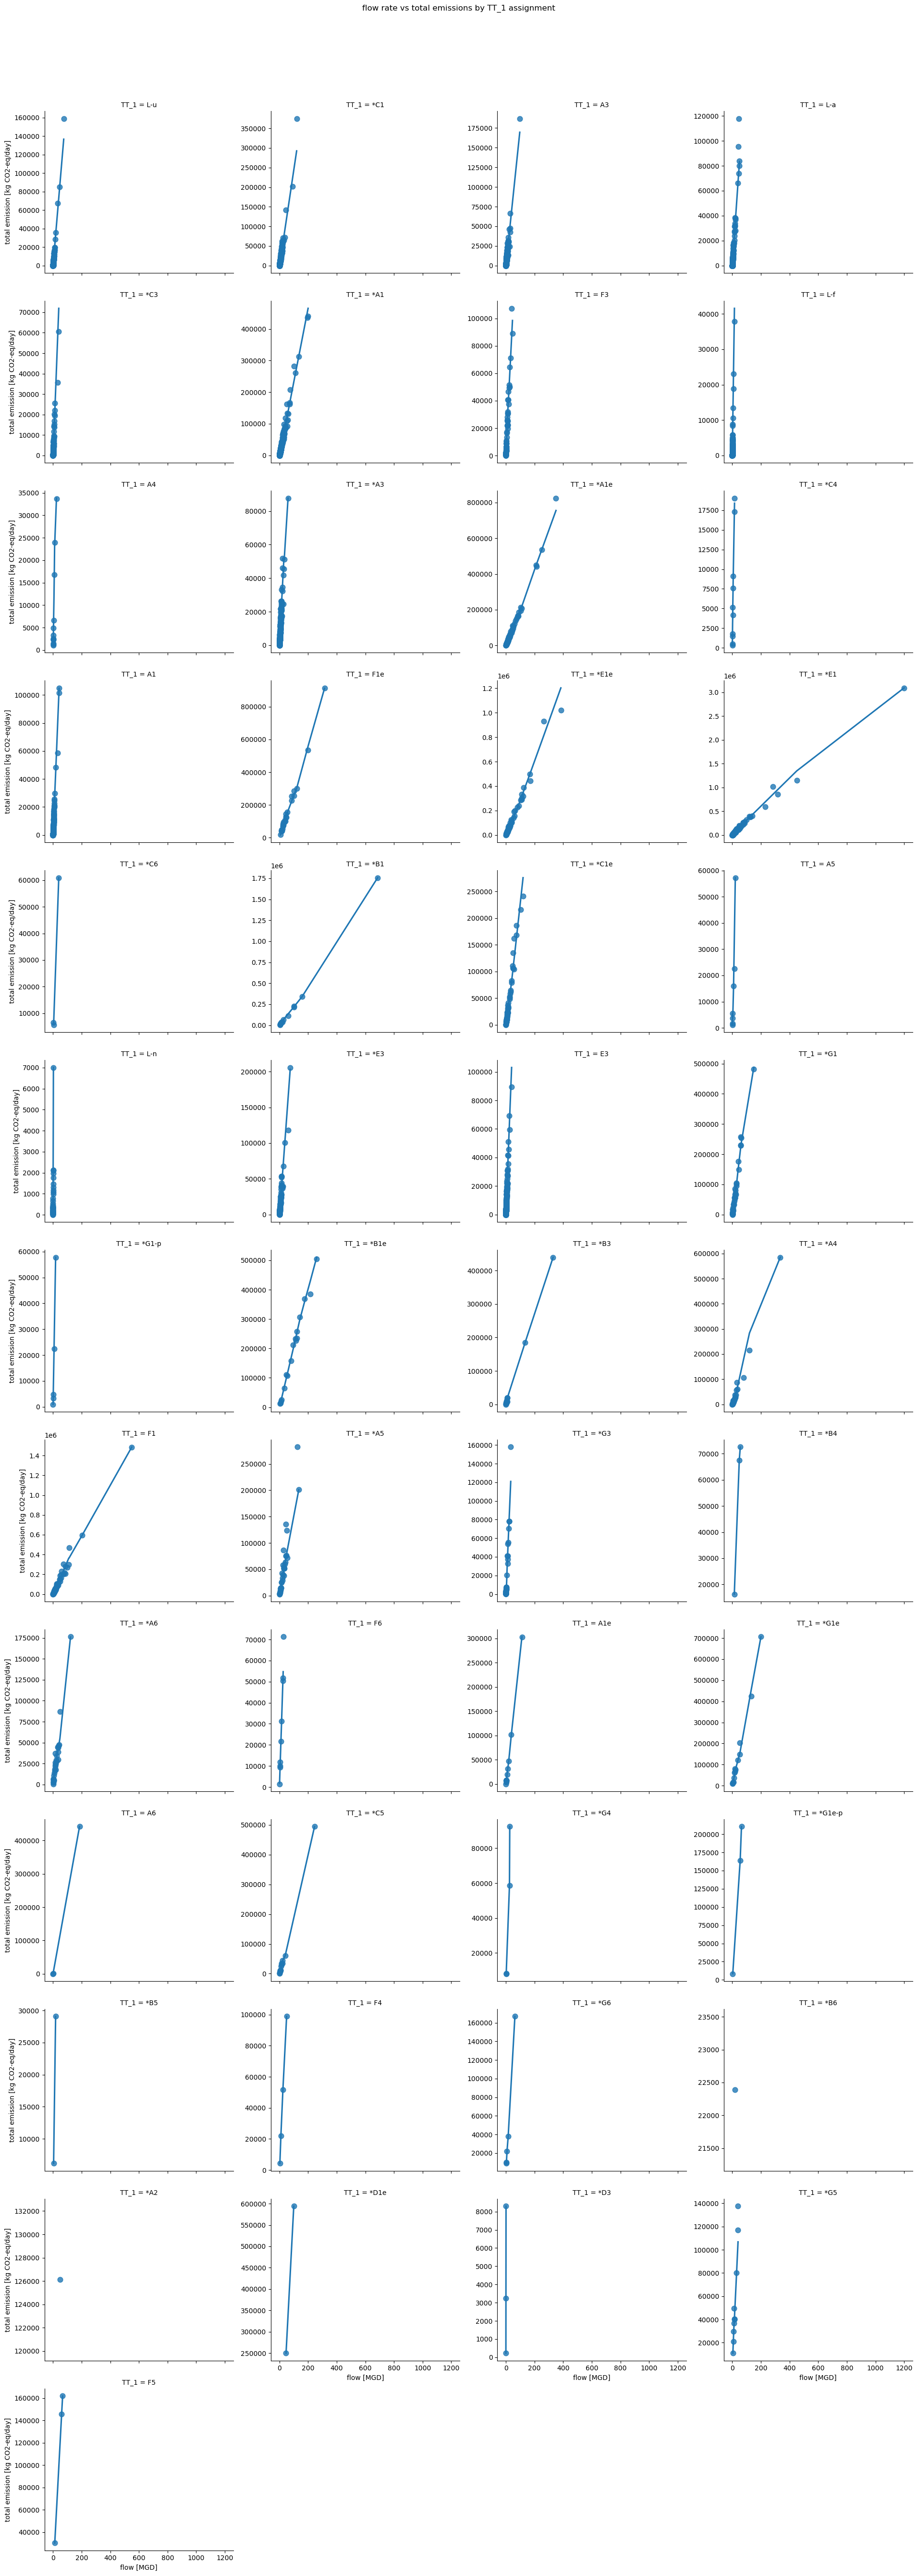

In [60]:
# flow rate vs total emissions by TT_1 assignment

sns.lmplot(
    data=df_SI_C_1,
    x='flow [MGD]',
    y='total emission [kg CO2-eq/day]',
    col='TT_1',       # Facet by group
    col_wrap=4,
    lowess=True,       # Add smoother fit, change to False for linear fit
    height=4,
    aspect=1.2,
    scatter_kws={'s': 60},
    facet_kws={'sharey': False}, # separate y-axis scales
)

plt.suptitle('flow rate vs total emissions by TT_1 assignment', y=1.03)
plt.tight_layout()
plt.show()